# Testing behaviour on StrategyA

This version of the strategy liquidates at the end of (15:00 and beyond) on the next day. 
It tests options maturing in 30 days only using short horizon MFIV(5H).
It does not save results. 
The purpose of this file is to compare the effect of working with a different part of the vol surface altogethor.
The 30 day horizon is tested only to check the robustness of the strategy when dealing with that part of the surface.

### IMPORTS

In [11]:
YEARS = [2019, 2020, 2021]

In [12]:
import sys, os
sys.path.insert(0, "/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")
sys.modules.pop("src", None)
os.chdir("/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")

In [13]:
import pandas as pd
import numpy as np
from math import sqrt, pi, exp
from arch import arch_model
import yfinance as yf 
from scipy.optimize import minimize
import warnings
from arch.__future__ import reindexing
from arch.utility.exceptions import ConvergenceWarning
from src.msGarch import msGARCH
from src.metrics import metrics
from src.msGarch import msGARCHIV
from tqdm import tqdm

from xgboost import XGBRegressor
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="y is poorly scaled")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [4]:
# import sys
# !{sys.executable} -m pip install xgboost

In [5]:
# # DO NOT RUN UNTIL CHANGES TO DEPENDENCIES 
# pip freeze > requirements.txt

### Load both data sets by year and quarter


In [23]:

# d_btc = pd.read_parquet("..\data\rawDatabtc_underlying_minutely_2019.parquet")
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2019.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

In [24]:
# Options with minutely data 
df = pd.read_parquet("../data/rawData/derivative_data_2019.parquet")

In [85]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/rawData")
YEARS = [2019, 2020, 2021]

d_btc_raw_by_year = {}
df_raw_by_year = {}

for y in YEARS:
    d_btc_raw_by_year[y] = pd.read_parquet(DATA_DIR / f"btc_underlying_minutely_{y}.parquet")
    df_raw_by_year[y]    = pd.read_parquet(DATA_DIR / f"derivative_data_{y}.parquet")


### Data Prep

In [10]:

from src.dataPrep import dataprep

d_btc_by_year = {}
df_by_year = {}

for y in YEARS:
    d_btc = d_btc_raw_by_year[y]
    df    = df_raw_by_year[y]

    prep = dataprep(d_btc=d_btc, df=df)
    d_btc_by_year[y], df_by_year[y] = prep.run_all()


### Prepare MFIV 

In [ ]:
from src.interpol import MFIVPipeline

In [ ]:
from src.interpol import MFIVPipeline
import numpy as np
import pandas as pd

q = 0.0
HOURS = [5, 20, 30, 40]

X_by_year = {}
MFIV_by_year = {}

for y in YEARS:
    d_btc = d_btc_by_year[y].copy()
    df    = df_by_year[y]

    for H in HOURS:
        T = H / (24.0 * 365.0)
        d_btc[f"F{H}"] = d_btc["Close"] * np.exp((d_btc["rfr"] - q) * T)

    idx = d_btc.index.tz_localize("UTC") if d_btc.index.tz is None else d_btc.index.tz_convert("UTC")
    rt  = d_btc["r"].reindex(idx)

    pipe = MFIVPipeline(df=df, d_btc=d_btc, q=0.0)
    pipe.build_surfaces()
    MFIV_byH = pipe.compute_mfiv_byH(H_LIST=[5])

    mf = MFIV_byH[5].reindex(idx.tz_convert(None))
    bsiv = mf["bsIV"].to_numpy()
    mfiv = mf["MFIV"].to_numpy()

    X_by_year[y] = pd.DataFrame({"rt": rt.values, "bsIV": bsiv, "MFIV": mfiv}, index=idx)
    MFIV_by_year[y] = MFIV_byH


In [ ]:
from pathlib import Path

OUTDIR = Path("../data/readyData")
OUTDIR.mkdir(parents=True, exist_ok=True)

for y, X in X_by_year.items():
    X.to_parquet(OUTDIR / f"d_X_{y}.parquet")


###  Load parameters : X_by_year (NEXT : Load saved)

In [25]:

import pandas as pd
from pathlib import Path

INDIR = Path("../data/readyData")
YEARS = [2019, 2020, 2021]

X_by_year = {y: pd.read_parquet(INDIR / f"d_X_{y}.parquet") for y in YEARS}


In [26]:
X_by_year[2019]

,rt,bsIV,MFIV
date_time,,,
2018-12-31 23:00:00+00:00,NaN,NaN,NaN
2019-01-01 00:00:00+00:00,0.000135,NaN,NaN
2019-01-01 01:00:00+00:00,-0.004202,NaN,NaN
2019-01-01 02:00:00+00:00,0.000000,NaN,NaN
2019-01-01 03:00:00+00:00,0.002035,NaN,NaN
...,...,...,...
2020-01-01 18:00:00+00:00,-0.000346,NaN,NaN
2020-01-01 19:00:00+00:00,-0.001386,NaN,NaN
2020-01-01 20:00:00+00:00,0.001039,NaN,NaN


In [27]:
import numpy as np

eps = 1e-12
for y, X in X_by_year.items():
    X_by_year[y][["bsIV","MFIV"]] = np.exp(
        np.log(X[["bsIV","MFIV"]].clip(lower=eps))
          .interpolate(method="time", limit_direction="both")
    )


In [28]:
# separated nested dict with year(2002) and quarters("q1") 
# X  : rt , bsIV , MFIV
Xq_by_year = {}

for y, X in X_by_year.items():
    Xq_by_year[y] = {
        "q1": X.loc[f"{y}-01-01":f"{y}-03-31 23:59:59"],
        "q2": X.loc[f"{y}-04-01":f"{y}-06-30 23:59:59"],
        "q3": X.loc[f"{y}-07-01":f"{y}-09-30 23:59:59"],
        "q4": X.loc[f"{y}-10-01":f"{y}-12-31 23:59:59"],
    }

# example: Xq_by_year[2025]["q1"]


In [29]:
Xq_by_year[2019]["q1"]

,rt,bsIV,MFIV
date_time,,,
2019-01-01 00:00:00+00:00,0.000135,5.000000,99.647859
2019-01-01 01:00:00+00:00,-0.004202,5.000000,99.647859
2019-01-01 02:00:00+00:00,0.000000,5.000000,99.647859
2019-01-01 03:00:00+00:00,0.002035,5.000000,99.647859
2019-01-01 04:00:00+00:00,0.000271,5.000000,99.647859
...,...,...,...
2019-03-31 19:00:00+00:00,0.000489,0.000001,10.119406
2019-03-31 20:00:00+00:00,-0.000183,0.000001,9.874937
2019-03-31 21:00:00+00:00,-0.001528,0.000001,9.636373


In [30]:
# these are forecasts made by each model at t-1 aligned with t  
Xq_by_year[2019]["q1"].columns

Index(['rt', 'bsIV', 'MFIV'], dtype='str')

### Base Model (3 Regime MS-GARCH) 


In [ ]:
from src.msGarch import msGARCH
from src.msGarch import msGARCHIV
from src.LSTM_lib import LSTMGatedIVCorrection

In [ ]:
from src.msGarch import msGARCH
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm
import numpy as np

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}
        regime_by_year[y] = {}

    ms = msGARCH()
    prev_theta = ms.theta0.copy()

    regimeB, f_rollB, idx = [], [], []
    dt = Xq.index.tz_convert(None).to_pydatetime()
    Xn = Xq.to_numpy(dtype=float)

    for i in tqdm(range(10, len(Xn)), total=len(range(10, len(Xn))), desc=f"{y}_{q}"):

        r_sub = Xn[i-10:i, 0]
        mu = r_sub.mean()
        sigma = r_sub.std() or 1.0
        r_std = (r_sub - mu) / sigma

        res = minimize(
            ms.nll_ms_garch,
            prev_theta,
            args=(r_std, 3),
            method="L-BFGS-B",
            options={"maxiter": 300, "ftol": 1e-5}
        )

        theta_i = prev_theta if (not res.success or not np.isfinite(res.fun)) else res.x
        prev_theta = theta_i

        f_next, reg = ms.forecast_var_k(r_std, theta_i, R=3, k=1)
        f_next = f_next * (sigma**2)

        regimeB.append(reg[-1])
        f_rollB.append(f_next[-1])
        idx.append(i)

    f_rollB = np.array(f_rollB)
    idx = np.array(idx)

    x_plotB = dt[idx]
    y_true = Xn[idx, 0]**2

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true
    regime_by_year[y][q] = regimeB

    plt.figure(figsize=(6, 3))
    plt.plot(x_plotB, y_true, label="Realized Var", linewidth=1)
    plt.plot(x_plotB, f_rollB, label="Rolling 1-Step Forecast", linewidth=1)
    plt.plot(x_plotB, np.array(regimeB)[:, 1] * 0.9 * plt.ylim()[1], color="black", alpha=0.6)
    plt.title(f"{y}_{q}")
    plt.tight_layout()
    plt.show()

In [ ]:
# import pickle

# save_dict = {
#     "idx_by_year": idx_by_year,
#     "f_rollB_by_year": f_rollB_by_year,
#     "rolling_forecasts": rolling_forecasts,
#     "rolling_residuals": rolling_residuals,
#     "y_pred_by_year": y_pred_by_year,
#     "y_true_by_year": y_true_by_year,
#     "regime_by_year": regime_by_year,
# }

# with open("../model_outputs_19_22/ms_garch_base_outputs.pkl", "wb") as f:
#     pickle.dump(save_dict, f)

### Base Model (3 Regime MS-GARCH) **vs** gated IV correction

In [92]:
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import torch
import torch.nn as nn


class LSTMGatedIVCorrection(nn.Module):
    """
    ADDITIVE gated blend in LEVELS:
        h_hat_t = (1 - w_t) * h_base_t + w_t * h_iv_t

    To keep your caller code almost unchanged, predict() returns g_hat such that:
        h_final = h_base2 * np.exp(g_hat)
    matches the additive blend exactly by setting:
        g_hat_t = log( h_hat_t / h_base_t )
    """

    def __init__(self, hidden_dim=32, lr=1e-3, epochs=30, batch_size=256, seed=42, device=None):
        super().__init__()
        torch.manual_seed(seed)
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # input: [bsIV, MFIV] -> LSTM -> gate w_t
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, 1)

        self.to(self.device)
        self.last_w = None

    @staticmethod
    def _to_tensor(x, device):
        if isinstance(x, torch.Tensor):
            return x.to(device)
        return torch.tensor(x, dtype=torch.float32, device=device)

    def forward(self, X_seq):
        out, _ = self.lstm(X_seq)          # (B, T, H)
        hT = out[:, -1, :]                 # (B, H)
        w = torch.sigmoid(self.head(hT))   # (B, 1) in [0,1]
        return w

    def fit_xy(self, X_seq, rv, h_base2, h_iv2):
        """
        X_seq:   (N, SEQ_LEN, 2)
        rv:      (N, 1) or (N,) realized variance target in LEVELS (NOT logs)
        h_base2: (N,)    base variance aligned to the same N rows
        h_iv2:   (N,)    IV variance proxy aligned to the same N rows
        """
        X_seq = self._to_tensor(X_seq, self.device)

        rv = np.asarray(rv, float).reshape(-1)
        hb = np.asarray(h_base2, float).reshape(-1)
        hi = np.asarray(h_iv2,   float).reshape(-1)

        eps = 1e-12
        rv_t = self._to_tensor(rv.reshape(-1, 1), self.device)
        hb_t = self._to_tensor(np.maximum(hb, eps).reshape(-1, 1), self.device)
        hi_t = self._to_tensor(np.maximum(hi, eps).reshape(-1, 1), self.device)

        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

        N = X_seq.shape[0]
        for _ in range(self.epochs):
            perm = torch.randperm(N, device=self.device)
            for s in range(0, N, self.batch_size):
                ii = perm[s:s+self.batch_size]
                Xb, rvb, hbb, hib = X_seq[ii], rv_t[ii], hb_t[ii], hi_t[ii]

                w = self.forward(Xb)
                h_hat = (1.0 - w) * hbb + w * hib   # ADDITIVE blend in levels

                loss = loss_fn(h_hat, rvb)
                opt.zero_grad()
                loss.backward()
                opt.step()

        return self

    @torch.no_grad()
    def predict(self, X_seq, h_base2, h_iv2):
        """
        Returns g_hat so your existing caller line can stay:
            h_final = h_base2 * np.exp(g_hat)

        Internally we compute:
            h_hat = (1-w)*h_base + w*h_iv
            g_hat = log(h_hat / h_base)
        """
        X_seq = self._to_tensor(X_seq, self.device)

        hb = np.asarray(h_base2, float).reshape(-1)
        hi = np.asarray(h_iv2,   float).reshape(-1)

        eps = 1e-12
        hb_t = self._to_tensor(np.maximum(hb, eps).reshape(-1, 1), self.device)
        hi_t = self._to_tensor(np.maximum(hi, eps).reshape(-1, 1), self.device)

        w = self.forward(X_seq)
        self.last_w = w.detach().cpu().numpy()

        h_hat = (1.0 - w) * hb_t + w * hi_t
        g_hat = torch.log(torch.clamp(h_hat / hb_t, min=eps))

        return g_hat.detach().cpu().numpy()


In [ ]:
# Requires : idx_by_year[y][q], f_rollB_by_year[y][q]
# MS-GARCH base + LSTM correction (w IV) per quarter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]

h_final_byQ = {}
g_hat_byQ   = {}
w_byQ       = {}

tables_gatedIV = {}
rv2_gatedIV_by_year = {}
h_base2_gatedIV_by_year = {}

for y, q, Xq in quarters:

    idx_q    = np.asarray(idx_by_year [y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt","bsIV","MFIV"]].copy()

    h_base_s = pd.Series(np.asarray(f_roll_q, float), index=t_idx)

    mask = df_use.notna().all(axis=1) & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)

    SEQ_LEN = 5
    feats = df_use[["bsIV","MFIV"]].to_numpy(np.float32)
    X_seq = []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
    X_seq = torch.tensor(np.stack(X_seq))

    h_base2 = h_base[SEQ_LEN:]
    H = 5
    dt_years = H / (365.25 * 24.0)
    mfiv_H = np.maximum(df_use["MFIV"].shift(1).to_numpy(float) * dt_years, 1e-12)  # No lookahead

    scale = np.nanmedian(h_base2) / np.nanmedian(mfiv_H[SEQ_LEN:])
    h_iv2 = np.maximum(mfiv_H[SEQ_LEN:] * scale, 1e-12)

    rv2 = rv[SEQ_LEN:]

    g_hat = np.full(len(rv2), np.nan, dtype=float)
    last_w = None

    for t in range(1, len(rv2)):
        lstm_corr = LSTMGatedIVCorrection(hidden_dim=32, lr=1e-3, epochs=30, device="cpu").fit_xy(
            X_seq[:t], rv2[:t], h_base2[:t], h_iv2[:t]
        )
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1], h_base2[t:t+1], h_iv2[t:t+1]).ravel()[0]
        last_w = getattr(lstm_corr, "last_w", None)

    h_base2 = h_base2[1:]
    h_iv2   = h_iv2[1:]
    rv2     = rv2[1:]
    g_hat   = g_hat[1:]
    h_final = h_base2 * np.exp(g_hat)

    if y not in h_final_byQ:
        h_final_byQ[y] = {}
        g_hat_byQ[y] = {}
        w_byQ[y] = {}
        tables_gatedIV[y] = {}
        rv2_gatedIV_by_year[y] = {}
        h_base2_gatedIV_by_year[y] = {}

    h_final_byQ[y][q] = h_final #  h is base forecast variance as numpy array
    g_hat_byQ[y][q]   = g_hat # g is predicted log correction term  |-|-|  g_hat ≈ log(rv / h_base)
    w_byQ[y][q]       = last_w

    x_plot2 = df_use.index[SEQ_LEN:][1:]

    rv2_gatedIV_by_year[y][q]     = rv2
    h_base2_gatedIV_by_year[y][q] = h_base2

    plt.figure(figsize=(6,3))
    plt.plot(x_plot2, rv2,     linewidth=1, label="Realized Var")
    plt.plot(x_plot2, h_base2, linewidth=1, label="MS-GARCH base")
    plt.plot(x_plot2, h_final, linewidth=1, label="MS-GARCH + gated IV correction")
    plt.title(f"{y}_{q}"); plt.legend(); plt.tight_layout(); plt.show()

    results = {}
    results["MS_base"]      = metrics(rv2, h_base2)
    results["MS_gatedIV"]   = metrics(rv2, h_final)

    table = pd.DataFrame(results, index=["RMSE","MAE","NLL","QLIKE","Bias"]).T.round(6)
    tables_gatedIV[y][q] = table
    print(f"{y}_{q}")
    print(table)
    

KeyError: 2019

In [ ]:
# # Check before running 
# import pickle

# save_dict = {
#     "h_final_byQ": h_final_byQ,
#     "g_hat_byQ": g_hat_byQ,
#     "w_byQ": w_byQ,
#     "tables_gatedIV": tables_gatedIV,
#     "rv2_gatedIV_by_year": rv2_gatedIV_by_year,
#     "h_base2_gatedIV_by_year": h_base2_gatedIV_by_year,
#     "quarters": quarters,
# }

# with open("../model_outputs_19_22/ms_garch_gatedIV_outputs.pkl", "wb") as f:
#     pickle.dump(save_dict, f)

### NoIV version LSTM forecast
 

In [63]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]


In [64]:
from src.LSTM_lib import LSTMcorrNoIV

In [65]:

h_base2_noIV_by_year = {}
rv2_noIV_by_year = {}
h_final_noIV_by_year = {}

for y, q, Xq in quarters:

    if y not in h_base2_noIV_by_year:
        h_base2_noIV_by_year[y] = {}
        rv2_noIV_by_year[y] = {}
        h_final_noIV_by_year[y] = {}

    idx_q    = np.asarray(idx_by_year[y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt"]].copy()

    h_base_s = pd.Series(f_roll_q, index=t_idx)

    mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)
    g  = np.log(rv + 1e-12) - np.log(h_base + 1e-12)

    SEQ_LEN = 5
    feats = df_use[["rt"]].to_numpy(np.float32)

    X_seq, y_seq = [], []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
        y_seq.append(g[i])

    X_seq = torch.tensor(np.stack(X_seq))
    y_seq = torch.tensor(np.array(y_seq, np.float32)).view(-1, 1)

    g_hat = np.full(len(y_seq), np.nan, dtype=float)

    for t in range(1, len(y_seq)):
        lstm_corr = LSTMcorrNoIV(hidden_dim=32, lr=1e-3, epochs=30).fit_xy(X_seq[:t], y_seq[:t])
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1])[0]

    h_base2 = h_base[SEQ_LEN:][1:]
    rv2     = rv[SEQ_LEN:][1:]
    h_final = h_base2 * np.exp(g_hat[1:])

    # store aligned outputs
    h_base2_noIV_by_year[y][q] = h_base2
    rv2_noIV_by_year[y][q]     = rv2
    h_final_noIV_by_year[y][q] = h_final


KeyError: 2019

In [ ]:
import pickle

save_dict_noIV = {
    "h_base2_noIV_by_year": h_base2_noIV_by_year,
    "rv2_noIV_by_year": rv2_noIV_by_year,
    "h_final_noIV_by_year": h_final_noIV_by_year,
    "quarters": quarters,
}

with open("../model_outputs_19_22/ms_garch_noIV_outputs.pkl", "wb") as f:
    pickle.dump(save_dict_noIV, f)
    


### Crucial check

In [37]:
print(idx_by_year.keys())

dict_keys([2019, 2020, 2021])


### Load Saved MSGarch Outputs (NEXT : Main Index)

In [31]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_19_22/ms_garch_base_outputs.pkl","rb")))


In [32]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [33]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_19_22/ms_garch_gatedIV_outputs.pkl","rb")))


In [34]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [35]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_19_22/ms_garch_noIV_outputs.pkl","rb")))

In [36]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [21]:
[k for k in globals() if k.startswith("rv")]

['rv2_gatedIV_by_year', 'rv2_noIV_by_year']

In [74]:
Xq_by_year[2019]

{'q1':                                  rt      bsIV       MFIV
 date_time                                               
 2019-01-01 00:00:00+00:00  0.000135  5.000000  99.647859
 2019-01-01 01:00:00+00:00 -0.004202  5.000000  99.647859
 2019-01-01 02:00:00+00:00  0.000000  5.000000  99.647859
 2019-01-01 03:00:00+00:00  0.002035  5.000000  99.647859
 2019-01-01 04:00:00+00:00  0.000271  5.000000  99.647859
 ...                             ...       ...        ...
 2019-03-31 19:00:00+00:00  0.000489  0.000001  10.119406
 2019-03-31 20:00:00+00:00 -0.000183  0.000001   9.874937
 2019-03-31 21:00:00+00:00 -0.001528  0.000001   9.636373
 2019-03-31 22:00:00+00:00  0.001345  0.000001   9.403573
 2019-03-31 23:00:00+00:00  0.000061  0.000001   9.176397
 
 [2160 rows x 3 columns],
 'q2':                                  rt      bsIV       MFIV
 date_time                                               
 2019-04-01 00:00:00+00:00  0.004450  0.000001   8.954709
 2019-04-01 01:00:00+00:00  0.00

### outputs_by_year

In [100]:
# NEW CELL
# Rebuilds and stores the aligned plotting index `x_plot2`
#   for each year and quarter without rerunning the model.
# Uses idx_by_year to align the forecasts to forecasting index.
x_plot2_by_year = {}

for y in YEARS:
    x_plot2_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        Xq = Xq_by_year[y][q]

        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [126]:
print(YEARS)
print(idx_by_year.keys())

[2019, 2020, 2021]
dict_keys([2019, 2020, 2021])


In [102]:
x_plot2_by_year = {}

for y in YEARS:
    if y not in idx_by_year or y not in f_rollB_by_year:
        print(f"Skipping year {y}: missing in saved results")
        continue

    x_plot2_by_year[y] = {}

    for q in ["q1", "q2", "q3", "q4"]:
        if q not in idx_by_year[y] or q not in f_rollB_by_year[y]:
            print(f"Skipping {y} {q}: missing quarter data")
            continue

        Xq = Xq_by_year[y][q]
        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [128]:
[k for k in globals() if k.startswith("rv")]

['rv2_gatedIV_by_year', 'rv2_noIV_by_year']

In [140]:
import pandas as pd

outputs_by_year = {
    y: {
        q: pd.DataFrame(
            {
                "rv": rv2_gatedIV_by_year[y][q],
                "ms_base": h_base2_gatedIV_by_year[y][q],
                "ms_LSTM_noIV": h_final_noIV_by_year[y][q],
                "ms_LSTM_wIV": h_final_byQ[y][q],
            },
            index=x_plot2_by_year[y][q]
        )
        for q in ["q1", "q2", "q3", "q4"]
    }
    for y in YEARS
}

In [141]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV
date_time,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020
...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001


In [142]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

### AR10

In [30]:
def estimate_ar10(Xq):
    f_rollB, y_true, idx = [], [], []
    Xn = Xq.to_numpy(dtype=float)

    for i in range(10, len(Xn)):
        r_sub = Xn[i-10:i, 0]

        phi = r_sub.mean()
        f_next = phi

        f_rollB.append(f_next)
        y_true.append(Xn[i, 0])
        idx.append(i)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [31]:
for y, q, Xq in quarters:

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_ar10(Xq_df)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

In [32]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["ar10"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )

### GARCH

In [35]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt

def estimate_garch(Xq):
    f_rollB, y_true, idx = [], [], []
    Xn = Xq.to_numpy(dtype=float)

    for i in range(10, len(Xn)):
        r_sub = Xn[i-10:i, 0]

        am = arch_model(r_sub, mean="Constant", vol="GARCH", p=1, q=1, rescale=False)
        res = am.fit(disp="off", show_warning=False)

        f_next = res.forecast(horizon=1).variance.values[-1, 0]

        f_rollB.append(f_next)
        y_true.append(Xn[i, 0] ** 2)
        idx.append(i)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [36]:

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_garch(Xq_df)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    # plt.figure(figsize=(6, 3))
    # plt.plot(x_plotB, y_true, label="Realized Var", linewidth=1)
    # plt.plot(x_plotB, f_rollB, label="Rolling 1-Step Forecast", linewidth=1)
    # plt.title(f"{y}_{q}")
    # plt.tight_layout()
    # plt.show()

In [ ]:
outputs_by_year[2022]['q2']

In [37]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["garch"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )

In [39]:
outputs_by_year[2019]['q2']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch
date_time,,,,,,
2019-04-01 16:00:00+00:00,3.982364e-06,0.000002,0.000001,0.000005,0.000230,0.000002
2019-04-01 17:00:00+00:00,2.866142e-06,0.000003,0.000002,0.000010,0.000351,0.000002
2019-04-01 18:00:00+00:00,1.795135e-07,0.000003,0.000003,0.000021,0.000297,0.000003
2019-04-01 19:00:00+00:00,1.060303e-06,0.000003,0.000002,0.000046,0.000285,0.000002
2019-04-01 20:00:00+00:00,1.468882e-08,0.000003,0.000002,0.000039,0.000200,0.000003
...,...,...,...,...,...,...
2019-06-30 19:00:00+00:00,1.472568e-05,0.000248,0.000188,0.000151,-0.005175,0.000262
2019-06-30 20:00:00+00:00,2.232283e-04,0.000255,0.000208,0.000126,-0.004681,0.000148
2019-06-30 21:00:00+00:00,1.357369e-04,0.000246,0.000156,0.000122,-0.000900,0.000138


In [ ]:
# #temporary
# import pickle
# pickle.dump(outputs_by_year, open("../outputs_by_year/2019_2022/outputs_by_year_5mdls.pkl", "wb"))

In [42]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2019_2022/outputs_by_year_5mdls.pkl", "rb"))

### XGBoost

In [43]:
from xgboost import XGBRegressor
import numpy as np

def estimate_xgboost(Xq_df, target_col="rv", lookback=10):
    f_rollB = []
    y_true = []
    idx = []

    for t in range(lookback, len(Xq_df)):
        train = Xq_df.iloc[t - lookback:t]
        test = Xq_df.iloc[[t]]

        X_train = train.drop(columns=[target_col])
        y_train = train[target_col]

        X_test = test.drop(columns=[target_col])
        y_test = test[target_col].iloc[0]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            objective="reg:squarederror",
            random_state=42
        )
        model.fit(X_train, y_train)

        pred = model.predict(X_test)[0]

        f_rollB.append(pred)
        y_true.append(y_test)
        idx.append(t)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [44]:
# YEARS = [2022, 2023, 2024, 2025]
YEARS = [2019, 2020, 2021]

In [45]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        Xq_by_year[y][q]["rv"] = Xq_by_year[y][q]["rt"] ** 2

In [46]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_xgboost(Xq_df, target_col="rv", lookback=10)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

In [48]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["xg_boost"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )

import pyttsx3


In [50]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost
date_time,,,,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012,-0.000393,0.000011,0.000011
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012,-0.000149,0.000013,0.000012
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011,-0.000541,0.000010,0.000011
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014,-0.001492,0.000015,0.000017
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020,0.000014,0.000056,0.000026
...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002


### SV

In [51]:
import numpy as np
from statsmodels.tsa.statespace.structural import UnobservedComponents

def estimate_sv(Xq_df, return_col="rt", lookback=10, eps=1e-6):
    f_rollB, y_true, idx = [], [], []
    # 1. Scale returns by 100 to stabilize log calculation
    r_orig = Xq_df[return_col].astype(float).to_numpy()
    r_scaled = r_orig * 100

    for t in range(lookback, len(r_scaled)):
        # 2. Use scaled returns for the log-variance proxy
        y = np.log(r_scaled[t - lookback:t] ** 2 + eps)

        try:
            # Local level model is the standard state-space approximation for SV
            res = UnobservedComponents(y, level="local level").fit(disp=False)
            m = float(res.forecast(1)[0])
            # Forecast error covariance
            v = float(res.filter_results.forecasts_error_cov[0, 0, -1]) if res.filter_results.forecasts_error_cov.size else 0.0
            
            # 3. Exponentiate and scale back down (divide by 100^2 = 10000)
            f_next = np.exp(m + 0.5 * max(v, 0.0)) / 10000
        except Exception:
            # Robust fallback: Simple Moving Average of squared returns
            f_next = float(np.mean(r_orig[t - lookback:t] ** 2))

        f_rollB.append(f_next)
        y_true.append(r_orig[t] ** 2)
        idx.append(t)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [52]:
for y, q, Xq_df in quarters:
    f_rollB, y_true, idx = estimate_sv(Xq_df, return_col="rt", lookback=10)
    outputs_by_year[y][q]["sv"] = pd.Series(f_rollB, index=Xq_by_year[y][q].index[idx])

In [53]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv
date_time,,,,,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012,-0.000393,0.000011,0.000011,0.000065
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012,-0.000149,0.000013,0.000012,0.000037
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011,-0.000541,0.000010,0.000011,0.000056
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014,-0.001492,0.000015,0.000017,0.000126
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020,0.000014,0.000056,0.000026,0.000228
...,...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002,0.000007
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002,0.000004
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002,0.000002


### GJR-GARCH

In [54]:
from arch import arch_model

def estimate_garch_variant(Xq_df, return_col="rt", lookback=10, variant='GJR'):
    """
    variant: 'GJR' (for GJR-GARCH) or 'EGARCH'
    """
    f_rollB, y_true, idx = [], [], []
    r_orig = Xq_df[return_col].astype(float).to_numpy()
    
    # Scale returns by 100 for optimizer stability
    r_scaled = r_orig * 100

    for t in range(lookback, len(r_scaled)):
        window = r_scaled[t - lookback:t]
        
        try:
            if variant == 'GJR':
                # p=1, o=1, q=1 is GJR-GARCH
                model = arch_model(window, p=1, o=1, q=1, vol='Garch', dist='t')
            else:
                model = arch_model(window, p=1, o=1, q=1, vol='EGARCH', dist='t')
            
            res = model.fit(disp='off', show_batch=False)
            # Forecast 1-step ahead variance
            f_scaled = res.forecast(horizon=1).variance.values[-1, 0]
            # Scale back down (divide by 100^2)
            f_next = f_scaled / 10000
        except Exception:
            f_next = float(np.mean(r_orig[t - lookback:t] ** 2))

        f_rollB.append(f_next)
        idx.append(t)

    return np.array(f_rollB), np.array(idx)

In [55]:
def estimate_parkinson(Xq_df, high_col="high", low_col="low", lookback=10):
    f_rollB, y_true, idx = [], [], []
    # Parkinson constant: 1 / (4 * ln(2))
    k = 1.0 / (4.0 * np.log(2.0))
    
    h = Xq_df[high_col].astype(float).to_numpy()
    l = Xq_df[low_col].astype(float).to_numpy()
    r = Xq_df["rt"].astype(float).to_numpy()

    for t in range(lookback, len(h)):
        # Range-based variance calculation
        window_h = h[t - lookback:t]
        window_l = l[t - lookback:t]
        
        # Log-range variance
        p_var = k * np.mean(np.log(window_h / window_l) ** 2)

        f_rollB.append(p_var)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [56]:
for y, q, Xq_df in quarters:
    # Fix GJR-GARCH
    f_gjr, idx_gjr = estimate_garch_variant(Xq_df, variant='GJR')
    outputs_by_year[y][q]["gjr"] = pd.Series(f_gjr, index=Xq_by_year[y][q].index[idx_gjr])

In [62]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr
date_time,,,,,,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012,-0.000393,0.000011,0.000011,0.000065,0.000011
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012,-0.000149,0.000013,0.000012,0.000037,0.000012
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011,-0.000541,0.000010,0.000011,0.000056,0.000011
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014,-0.001492,0.000015,0.000017,0.000126,0.000017
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020,0.000014,0.000056,0.000026,0.000228,0.000026
...,...,...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002,0.000007,0.000002
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002,0.000004,0.000002
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002,0.000002,0.000002


In [ ]:
# #temporary
# import pickle
# pickle.dump(outputs_by_year, open("../outputs_by_year/2019_2022/outputs_by_year_8mdls.pkl", "wb"))

In [ ]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2019_2022/outputs_by_year_8mdls.pkl", "rb"))

### E GARCH

In [64]:

for y, q, Xq_df in quarters:
    f_ega, idx_ega = estimate_garch_variant(Xq_df, variant='EGARCH')
    outputs_by_year[y][q]["egarch"] = pd.Series(f_ega, index=Xq_by_year[y][q].index[idx_ega])

### T ARCH

In [65]:
def estimate_tarch(Xq_df, return_col="rt", lookback=10):
    f_rollB, y_true, idx = [], [], []
    r = Xq_df[return_col].astype(float).to_numpy()
    for t in range(lookback, len(r)):
        y = r[t - lookback:t]
        try:
            # model='avgarch' implements the TARCH/ZARCH logic
            am = arch_model(y, vol='AVGARCH', p=1, o=1, q=1, dist='studentst', rescale=False)
            res = am.fit(disp="off", show_warning=False)
            f_next = res.forecast(horizon=1).variance.iloc[-1, 0]
        except:
            f_next = np.mean(r[t - lookback:t] ** 2)
        f_rollB.append(f_next)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [66]:
for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    
    f_rollB, y_true, idx = estimate_tarch(Xq_df, return_col="rt", lookback=10)

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    outputs_by_year[y][q]["tarch"] = pd.Series(f_rollB, index=Xq_df.index[idx])

In [68]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch
date_time,,,,,,,,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012,-0.000393,0.000011,0.000011,0.000065,0.000011,0.000011,0.000011
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012,-0.000149,0.000013,0.000012,0.000037,0.000012,0.000012,0.000012
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011,-0.000541,0.000010,0.000011,0.000056,0.000011,0.000011,0.000011
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014,-0.001492,0.000015,0.000017,0.000126,0.000017,0.000017,0.000017
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020,0.000014,0.000056,0.000026,0.000228,0.000026,0.000026,0.000026
...,...,...,...,...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002,0.000007,0.000002,0.000002,0.000002
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002,0.000004,0.000002,0.000002,0.000002
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002


In [69]:
#temporary
import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2019_2022/outputs_by_year_10mdls.pkl", "wb"))

### Midas

In [70]:
def estimate_midas(Xq_df, return_col="rt", lookback=10):
    f_rollB, y_true, idx = [], [], []
    r = Xq_df[return_col].astype(float).to_numpy()
    
    # Pre-calculate Almon weights (decaying influence)
    # This weights the most recent hours more heavily than the 10th hour
    weights = np.exp(-0.1 * np.arange(lookback))
    weights /= weights.sum()

    for t in range(lookback, len(r)):
        y_window = r[t - lookback:t] ** 2
        
        # MIDAS forecast is the weighted sum of past squared returns
        f_next = np.sum(weights * y_window)

        f_rollB.append(f_next)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [71]:
for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    
    f_rollB, y_true, idx = estimate_midas(Xq_df, return_col="rt", lookback=10)

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    outputs_by_year[y][q]["midas"] = pd.Series(f_rollB, index=Xq_df.index[idx])

### GARCH M

In [72]:
import numpy as np
import pandas as pd
from arch.univariate import ARCHInMean, GARCH, Normal

def estimate_garch_m(series):
    model = ARCHInMean(
        y=series,
        volatility=GARCH(p=1, q=1),
        distribution=Normal(),
        form="var",
        rescale=False
    )

    res = model.fit(disp="off", show_warning=False,options={"maxiter": 1000})

    params = res.params

    omega = float(params["omega"])
    alpha_name = [k for k in params.index if k.startswith("alpha[")][0]
    beta_name  = [k for k in params.index if k.startswith("beta[")][0]

    alpha = float(params[alpha_name])
    beta  = float(params[beta_name])

    last_resid = float(res.resid.iloc[-1] if hasattr(res.resid, "iloc") else res.resid[-1])
    last_h = float(
        (res.conditional_volatility.iloc[-1] if hasattr(res.conditional_volatility, "iloc")
         else res.conditional_volatility[-1]) ** 2
    )

    # Manual 1-step-ahead GARCH(1,1) variance forecast
    h_next = omega + alpha * (last_resid ** 2) + beta * last_h
    return h_next

In [73]:
Xq_by_year[2019]['q1']["rt"]

KeyError: 2022

In [74]:

for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    returns = Xq_df["rt"].astype(float) * 100.0

    f_garch_m = []
    idx_garch_m = []

    min_obs = 10

    for t in range(min_obs, len(returns)):
        train = returns.iloc[:t]

        try:
            # estimate on scaled returns, then scale variance back down
            fval = estimate_garch_m(train) / 10000.0
        except Exception:
            fval = np.nan

        f_garch_m.append(fval)
        idx_garch_m.append(t)

    idx_by_year[y][q] = np.array(idx_garch_m)
    f_rollB_by_year[y][q] = np.array(f_garch_m)
    rolling_forecasts[y][q] = np.array(f_garch_m)
    y_pred_by_year[y][q] = np.array(f_garch_m)
    y_true_by_year[y][q] = Xq_df["rv"].iloc[idx_garch_m].to_numpy() if "rv" in Xq_df.columns else np.full(len(idx_garch_m), np.nan)
    rolling_residuals[y][q] = y_true_by_year[y][q] - y_pred_by_year[y][q]

    outputs_by_year[y][q]["garch_m"] = pd.Series(f_garch_m, index=Xq_df.index[idx_garch_m])

In [77]:
outputs_by_year[2019]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch,midas,garch_m
date_time,,,,,,,,,,,,,
2019-01-01 16:00:00+00:00,7.368198e-06,0.000011,0.000015,0.000012,-0.000393,0.000011,0.000011,0.000065,0.000011,0.000011,0.000011,0.000010,0.002135
2019-01-01 17:00:00+00:00,7.350222e-08,0.000012,0.000016,0.000012,-0.000149,0.000013,0.000012,0.000037,0.000012,0.000012,0.000012,0.000011,0.000011
2019-01-01 18:00:00+00:00,6.671223e-05,0.000010,0.000006,0.000011,-0.000541,0.000010,0.000011,0.000056,0.000011,0.000011,0.000011,0.000010,0.000010
2019-01-01 19:00:00+00:00,1.068040e-04,0.000015,0.000011,0.000014,-0.001492,0.000015,0.000017,0.000126,0.000017,0.000017,0.000017,0.000015,0.000150
2019-01-01 20:00:00+00:00,3.848541e-05,0.000026,0.000022,0.000020,0.000014,0.000056,0.000026,0.000228,0.000026,0.000026,0.000026,0.000020,0.000057
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002,0.000007,0.000002,0.000002,0.000002,0.000002,0.000014
2019-03-31 20:00:00+00:00,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002,0.000004,0.000002,0.000002,0.000002,0.000002,0.000013
2019-03-31 21:00:00+00:00,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000013


In [ ]:

import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2019_2022/outputs_by_year_12mdls.pkl", "wb"))

In [ ]:

# Save globals output is a proxy only for quick plotting, I save the index, and results from only the ms_garch base model.

# import pickle

# pickle.dump(
#     {k: v for k, v in globals().items() if k in ["YEARS"] or k.startswith(("rv2_", "h_base2_", "h_final_", "x_plot2_"))},
#     open("globals.pkl", "wb")
# )

In [84]:
print([i for i in globals() if not i.startswith("__") and not i.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pickle', 'idx_by_year', 'f_rollB_by_year', 'rolling_forecasts', 'rolling_residuals', 'y_pred_by_year', 'y_true_by_year', 'regime_by_year', 'h_final_byQ', 'g_hat_byQ', 'w_byQ', 'tables_gatedIV', 'rv2_gatedIV_by_year', 'h_base2_gatedIV_by_year', 'quarters', 'h_base2_noIV_by_year', 'rv2_noIV_by_year', 'h_final_noIV_by_year', 'x_plot2_by_year', 'YEARS', 'y', 'q', 'sys', 'os', 'pd', 'np', 'sqrt', 'pi', 'exp', 'arch_model', 'yf', 'minimize', 'warnings', 'reindexing', 'ConvergenceWarning', 'msGARCH', 'metrics', 'msGARCHIV', 'tqdm', 'XGBRegressor', 'Path', 'INDIR', 'X_by_year', 'eps', 'X', 'Xq_by_year', 'Xq', 'idx_q', 'f_roll_q', 't_idx', 'df_use', 'h_base_s', 'mask', 'outputs_by_year', 'estimate_ar10', 'Xq_df', 'dt', 'f_rollB', 'y_true', 'idx', 'x_plotB', 'plt', 'estimate_garch', 'estimate_xgboost', 'pyttsx3', 'UnobservedComponents', 'estimate_sv', 'estimate_garch_variant', 'estimate_parkinson', 'f_gjr', 'idx_gjr', 'f_ega', 'idx_ega', 'est

### Main Index NEXT : Continue

In [43]:
# NEW CELL
# Rebuilds and stores the aligned plotting index `x_plot2`
#   for each year and quarter without rerunning the model.
# Uses idx_by_year to align the forecasts to forecasting index.
x_plot2_by_year = {}

for y in YEARS:
    x_plot2_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        Xq = Xq_by_year[y][q]

        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [108]:
idx_by_year[y]

{'q1': array([  10,   11,   12, ..., 2157, 2158, 2159], shape=(2150,)),
 'q2': array([  10,   11,   12, ..., 2181, 2182, 2183], shape=(2174,)),
 'q3': array([  10,   11,   12, ..., 2205, 2206, 2207], shape=(2198,)),
 'q4': array([  10,   11,   12, ..., 2205, 2206, 2207], shape=(2198,))}

In [109]:
print(list(globals().keys()))

['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'YEARS', '_i2', 'sys', 'os', '_i3', '_i4', 'pd', 'np', 'sqrt', 'pi', 'exp', 'arch_model', 'yf', 'minimize', 'warnings', 'reindexing', 'ConvergenceWarning', 'msGARCH', 'metrics', 'msGARCHIV', 'tqdm', 'XGBRegressor', '_i5', '_i6', '_i7', 'd_btc', '_i8', 'df', '_i9', 'Path', 'DATA_DIR', 'd_btc_raw_by_year', 'df_raw_by_year', 'y', '_i10', 'dataprep', 'd_btc_by_year', 'df_by_year', 'prep', '_i11', 'INDIR', 'X_by_year', '_i12', '_12', '_i13', 'eps', 'X', '_i14', 'Xq_by_year', '_i15', '_15', '_i16', '_16', '_i17', 'pickle', 'idx_by_year', 'f_rollB_by_year', 'rolling_forecasts', 'rolling_residuals', 'y_pred_by_year', 'y_true_by_year', 'regime_by_year', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', 'h_final_byQ', 'g_hat_byQ', 'w_byQ', 'tables_gatedIV',

In [110]:
# pickle.dump(outputs_by_year, open("outputs_by_year.pkl","wb"))

In [112]:
Xq_by_year[2019]['q1']

,rt,bsIV,MFIV
date_time,,,
2019-01-01 00:00:00+00:00,0.000135,5.000000,99.647859
2019-01-01 01:00:00+00:00,-0.004202,5.000000,99.647859
2019-01-01 02:00:00+00:00,0.000000,5.000000,99.647859
2019-01-01 03:00:00+00:00,0.002035,5.000000,99.647859
2019-01-01 04:00:00+00:00,0.000271,5.000000,99.647859
...,...,...,...
2019-03-31 19:00:00+00:00,0.000489,0.000001,10.119406
2019-03-31 20:00:00+00:00,-0.000183,0.000001,9.874937
2019-03-31 21:00:00+00:00,-0.001528,0.000001,9.636373


In [113]:
#DIAGNOSES, DELETE
# Xq_by_year[2019]["q1"]["rt"]
# Xq_by_year.keys()
# dict_keys([2019, 2020, 2021])

# Xq_by_year[2019]["q1"].index
# outputs_by_year[2019]
# Xq_by_year[2019]["q1"]["rt"]


### Output vs Realized

In [38]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2019_2022/outputs_by_year_12mdls.pkl", "rb"))

<Axes: title={'center': 'RV, ms-base, ms-gatedIV'}, xlabel='date_time'>

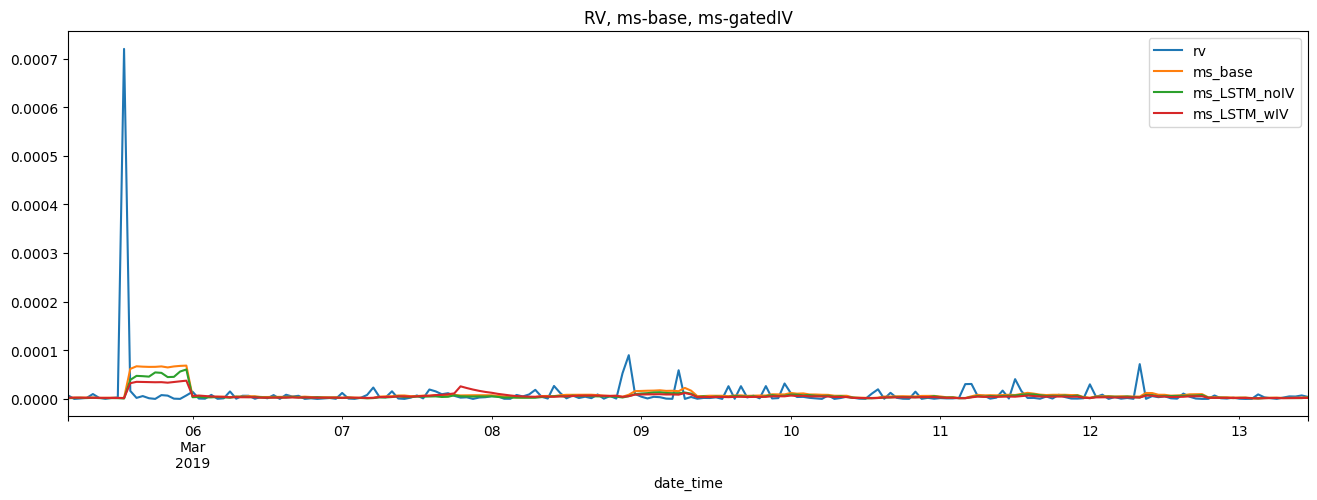

In [40]:
outputs_by_year[2019]['q1'][['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV']][1500:1700].plot(figsize=(16,5), title = "RV, ms-base, ms-gatedIV")


### Evaluation

In [41]:
def metrics_new(y_true, y_pred, eps=1e-10):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    m = min(len(y_true), len(y_pred))
    y_true = np.clip(y_true[-m:], eps, None)
    y_pred = np.clip(y_pred[-m:], eps, None)

    # Errors
    err = y_true - y_pred

    # Core
    mse  = np.mean(err**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(err))
    bias = np.mean(err)

    # Likelihood / variance metrics
    qlike = np.mean(np.log(y_pred) + y_true / y_pred)
    nll   = 0.5 * np.mean(np.log(2*np.pi) + np.log(y_pred) + y_true / y_pred)

    # Relative metrics
    hmse = np.mean((1 - y_true / y_pred)**2)
    hmae = np.mean(np.abs(1 - y_true / y_pred))

    # R2
    r2 = 1 - np.sum(err**2) / np.sum((y_true - np.mean(y_true))**2)

    # MADL (variance → signal)
    signal = y_pred - np.mean(y_pred)
    direction = np.sign(signal)
    madl = np.mean(-np.sign(y_true * direction) * np.abs(y_true))

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "NLL": nll,
        "QLIKE": qlike,
        "HMSE": hmse,
        "HMAE": hmae,
        "R2": r2,
        "Bias": bias,
        "MADL": madl
    }

In [42]:
outputs_by_year[2019]['q1'].columns

Index(['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m'],
      dtype='str')

In [145]:
from src.metrics import metrics
import numpy as np
import pandas as pd

quarters = [(y, q, Xq_by_year[y][q]) for y in sorted(Xq_by_year.keys()) for q in ["q1","q2","q3","q4"]]

tables_all = {}

for y, q, _ in quarters:
    results = {}

    rv2_q = np.asarray(rv2_gatedIV_by_year[y][q], float)

    # NEW: directly use dataframe columns
    df_q = outputs_by_year[y][q]

    ms_base_q      = df_q["ms_base"].to_numpy(float)
    ms_LSTM_noIV_q = df_q["ms_LSTM_noIV"].to_numpy(float)
    ms_LSTM_wIV_q  = df_q["ms_LSTM_wIV"].to_numpy(float)

    target_idx = df_q.index[-len(rv2_q):]

    garch_q    = df_q["garch"].reindex(target_idx).to_numpy(float)
    xgboost_q  = df_q["xg_boost"].reindex(target_idx).to_numpy(float)
    sv_q       = df_q["sv"].reindex(target_idx).to_numpy(float)
    gjr_q      = df_q["gjr"].reindex(target_idx).to_numpy(float)
    egarch_q   = df_q["egarch"].reindex(target_idx).to_numpy(float)
    tarch_q    = df_q["tarch"].reindex(target_idx).to_numpy(float)
    midas_q    = df_q["midas"].reindex(target_idx).to_numpy(float)
    garch_m_q  = df_q["garch_m"].reindex(target_idx).to_numpy(float)

    valid = (
        np.isfinite(rv2_q)
        & np.isfinite(ms_base_q)
        & np.isfinite(ms_LSTM_noIV_q)
        & np.isfinite(ms_LSTM_wIV_q)
        & np.isfinite(garch_q)
        & np.isfinite(xgboost_q)
        & np.isfinite(sv_q)
        & np.isfinite(gjr_q)
        & np.isfinite(egarch_q)
        & np.isfinite(tarch_q)
        & np.isfinite(midas_q)
        & np.isfinite(garch_m_q)
    )

    rv2_use         = rv2_q[valid]
    ms_base_use     = ms_base_q[valid]
    ms_LSTM_noIV_use= ms_LSTM_noIV_q[valid]
    ms_LSTM_wIV_use = ms_LSTM_wIV_q[valid]

    garch_use    = garch_q[valid]
    xgboost_use  = xgboost_q[valid]
    sv_use       = sv_q[valid]
    gjr_use      = gjr_q[valid]
    egarch_use   = egarch_q[valid]
    tarch_use    = tarch_q[valid]
    midas_use    = midas_q[valid]
    garch_m_use  = garch_m_q[valid]

    results["GARCH_M"]      = metrics_new(rv2_use, garch_m_use)
    results["MS_base"]      = metrics_new(rv2_use, ms_base_use)
    results["MS_LSTM_noIV"] = metrics_new(rv2_use, ms_LSTM_noIV_use)
    results["MS_LSTM_wIV"]  = metrics_new(rv2_use, ms_LSTM_wIV_use)
    results["GARCH"]        = metrics_new(rv2_use, garch_use)
    results["XGBoost"]      = metrics_new(rv2_use, xgboost_use)
    results["SV"]           = metrics_new(rv2_use, sv_use)
    results["GJR"]          = metrics_new(rv2_use, gjr_use)
    results["EGARCH"]       = metrics_new(rv2_use, egarch_use)
    results["TARCH"]        = metrics_new(rv2_use, tarch_use)
    results["MIDAS"]        = metrics_new(rv2_use, midas_use)

    metric_order = ["RMSE","MAE","MSE","NLL","QLIKE","HMSE","HMAE","R2","Bias","MADL"]
    table = pd.DataFrame(results).T[metric_order].round(6)

    if y not in tables_all:
        tables_all[y] = {}

    tables_all[y][q] = table

    print(f"{y}_{q}")
    print(table)

2019_q1
                  RMSE       MAE       MSE       NLL     QLIKE         HMSE  \
GARCH_M       0.000504  0.000055  0.000000 -3.923312 -9.684502   132.151915   
MS_base       0.000198  0.000031  0.000000 -2.866783 -7.571443  1813.100438   
MS_LSTM_noIV  0.000195  0.000027  0.000000 -2.054831 -5.947538  3802.105443   
MS_LSTM_wIV   0.000193  0.000026  0.000000 -3.407861 -8.653598   981.992428   
GARCH         0.000201  0.000031  0.000000 -2.882015 -7.601907  1837.328235   
XGBoost       0.000216  0.000029  0.000000 -3.074835 -7.987547  1473.705682   
SV            1.922343  0.059597  3.695401 -1.836147 -5.510171  5499.541583   
GJR           0.000200  0.000032  0.000000 -3.066395 -7.970668  1473.720300   
EGARCH        0.000200  0.000032  0.000000 -3.066395 -7.970668  1473.720300   
TARCH         0.000200  0.000032  0.000000 -3.066395 -7.970668  1473.720300   
MIDAS         0.000200  0.000032  0.000000 -3.000289 -7.838456  1452.634178   

                  HMAE            R2      B

### Residual Diagnostics

In [146]:
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

def residual_diagnostics_2019_2020(outputs_by_year, Xq_by_year):
    years = [2019, 2020]
    quarters = ["q1", "q2", "q3", "q4"]
    out = []

    for y in years:
        for q in quarters:
            if y not in outputs_by_year or q not in outputs_by_year[y]:
                continue
            if y not in Xq_by_year or q not in Xq_by_year[y]:
                continue

            df_pred = outputs_by_year[y][q].copy()
            df_x = Xq_by_year[y][q].copy()

            if "rt" not in df_x.columns:
                continue

            r = df_x["rt"].astype(float)
            common_idx = df_pred.index.intersection(r.index)

            if len(common_idx) == 0:
                continue

            r_use = r.reindex(common_idx).to_numpy(float)

            for model in df_pred.columns:
                h_use = pd.to_numeric(df_pred[model].reindex(common_idx), errors="coerce").to_numpy(float)

                valid = np.isfinite(r_use) & np.isfinite(h_use) & (h_use > 0)
                if valid.sum() < 20:
                    continue

                z = r_use[valid] / np.sqrt(h_use[valid])

                try:
                    lb_p = acorr_ljungbox(z, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
                except:
                    lb_p = np.nan

                try:
                    arch_p = het_arch(z, nlags=10)[1]
                except:
                    arch_p = np.nan

                try:
                    jb_p = jarque_bera(z)[1]
                except:
                    jb_p = np.nan

                out.append({
                    "Year": y,
                    "Quarter": q,
                    "Model": model,
                    "N": int(valid.sum()),
                    "LB_pvalue": lb_p,
                    "ARCH_pvalue": arch_p,
                    "JB_pvalue": jb_p
                })

    return pd.DataFrame(out).sort_values(["Year", "Quarter", "Model"]).reset_index(drop=True)


diag_table = residual_diagnostics_2019_2020(outputs_by_year, Xq_by_year)
print(diag_table)

     Year Quarter     Model     N  LB_pvalue  ARCH_pvalue     JB_pvalue
0    2019      q1      ar10  1121   0.094349     0.755622  0.000000e+00
1    2019      q1    egarch  2144   0.940665     0.999494  0.000000e+00
2    2019      q1     garch  2144   0.934198     0.999698  0.000000e+00
3    2019      q1   garch_m  2144   0.000990     0.946608  0.000000e+00
4    2019      q1       gjr  2144   0.940665     0.999494  0.000000e+00
..    ...     ...       ...   ...        ...          ...           ...
99   2020      q4   ms_base  2192   0.621103     0.155509  0.000000e+00
100  2020      q4        rv  2186   0.012109     1.000000  7.546232e-80
101  2020      q4        sv  2192   0.583834     0.999809  0.000000e+00
102  2020      q4     tarch  2192   0.685661     0.254377  0.000000e+00
103  2020      q4  xg_boost  2192   0.676825     0.252657  0.000000e+00

[104 rows x 7 columns]


In [147]:
summary_table = (
    diag_table.groupby("Model")[["LB_pvalue", "ARCH_pvalue", "JB_pvalue"]]
    .mean()
    .sort_index()
)

print(summary_table)

              LB_pvalue  ARCH_pvalue     JB_pvalue
Model                                             
ar10           0.513620     0.832662  0.000000e+00
egarch         0.714057     0.809915  0.000000e+00
garch          0.673956     0.825585  0.000000e+00
garch_m        0.314960     0.783542  0.000000e+00
gjr            0.714057     0.809915  0.000000e+00
midas          0.706471     0.754967  0.000000e+00
ms_LSTM_noIV   0.691652     0.882946  0.000000e+00
ms_LSTM_wIV    0.654364     0.836942  0.000000e+00
ms_base        0.689357     0.858320  0.000000e+00
rv             0.003953     1.000000  1.934658e-77
sv             0.702959     0.869347  0.000000e+00
tarch          0.714057     0.809915  0.000000e+00
xg_boost       0.706209     0.805392  0.000000e+00


In [148]:

outputs_by_year[2019]['q1'].columns

Index(['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m'],
      dtype='str')

<Axes: xlabel='date_time'>

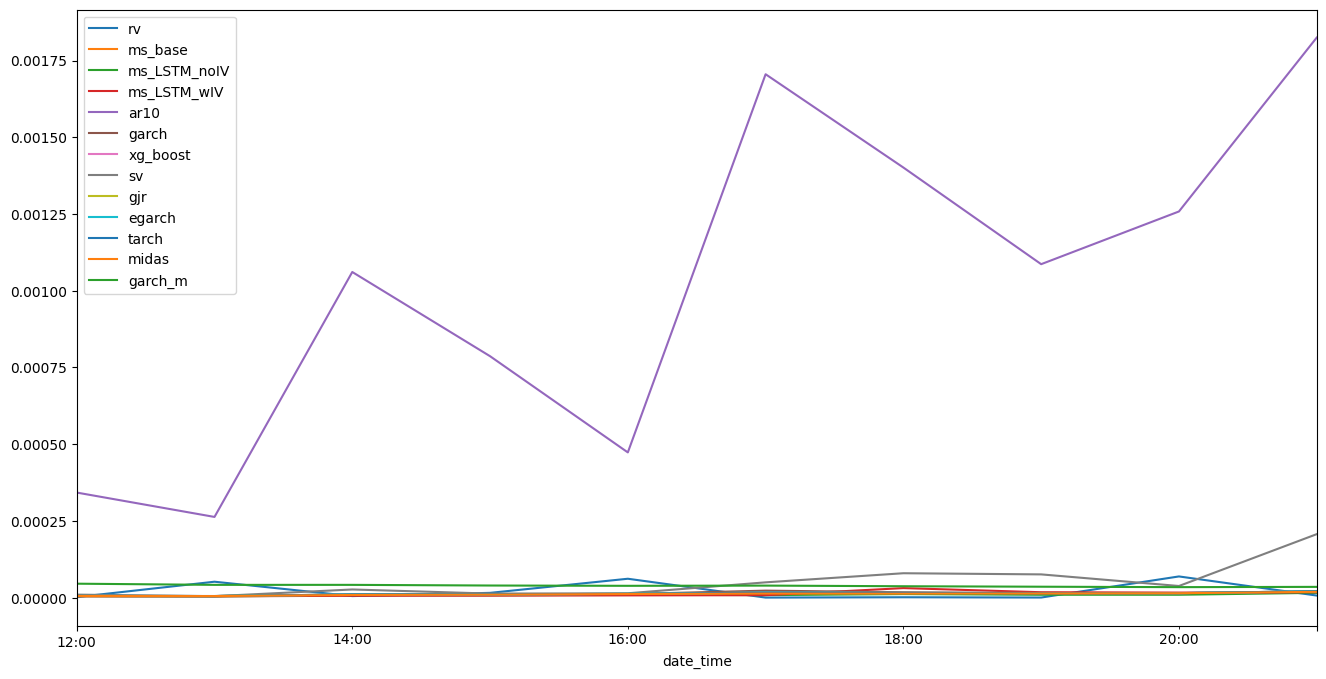

In [149]:

outputs_by_year[2019]['q1'][['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m']].iloc[20:30].plot(figsize = (16, 8))

### Prepare signals from the model 

In [150]:
def prepare_signals(Xq_by_year, outputs_by_year):
# this function builds a nested dictionary by year and quarter where each value is one DataFrame
    YEARS = [2019, 2020, 2021]
    quarters = ["q1", "q2", "q3", "q4"]
    # so our signal should have an up or down 
    
    out = {
        y: {
            q : pd.concat ( [Xq_by_year[y][q]["rt"], outputs_by_year[y][q]], axis = 1)
            for q in quarters
        }
        for y in YEARS
        }
    return out 
out = prepare_signals(Xq_by_year, outputs_by_year)



In [41]:
out[2019]['q1']

,rt,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch,midas,garch_m
date_time,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.000135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,-0.004202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,0.002035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,0.000271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-31 19:00:00+00:00,0.000489,2.388266e-07,0.000002,0.000001,0.000001,0.000214,0.000002,0.000002,0.000007,0.000002,0.000002,0.000002,0.000002,0.000014
2019-03-31 20:00:00+00:00,-0.000183,3.357473e-08,0.000002,0.000001,0.000001,0.000251,0.000002,0.000002,0.000004,0.000002,0.000002,0.000002,0.000002,0.000013
2019-03-31 21:00:00+00:00,-0.001528,2.335572e-06,0.000002,0.000001,0.000001,0.000098,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000013


### Logic and create out_full

In [43]:
out_full = pd.concat([out[y][q] for y in sorted(out) for q in ["q1","q2","q3","q4"]]).sort_index()

### Market 01

In [46]:
### New Market tesing

import pandas as pd
import numpy as np
from scipy.stats import norm


class Chain:
    def __init__(self):
        self.instruments = []

class Instrument:
    def __init__(self, symbol, strike, right, direction, price_per_contract, expiry ):
        self.Symbol = symbol
        self.Strike = strike
        self.Right = right
        self.Direction = direction
        self.Price = price_per_contract
        self.Expiry = expiry
class Holdings: 
    def __init__(self, cash, now):
        self.time = now
        self.instruments = [] # it has direction and all option contracts held at the moment
        self.cash = cash
        
    def get_cash(self):
        return self.cash

    def get_time(self):
        return self.time
        
    #later define your key as {strike, maturity, now}
    def long_instrument(self, instrument):
        self.instruments.append(instrument)

    def short_instrument(self, instrument):
        self.instruments.append(instrument)
    # later define key as key = (strike, expiry, Right,  direction)

    def close_position(self, key):
        strike, expiry, right,  direction = key
        self.instruments = [
            i for i in self.instruments
            if not (i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction)
        ]

class Market:
    def __init__(self, option_df, time_df, starting_cash=100000):
        self.time = time_df.index
        self.option = option_df.copy()
        self.chain = Chain()
        self.option_values = []
        self.time_df = time_df.copy()
        self.spot = None
        self.option["strike"] = self.option["instrument_name"].str.split("-").str[2].astype(float)
        self.option["type"] = self.option["instrument_name"].str.split("-").str[3]
        # self.option["maturity"] = pd.to_datetime(
        #     self.option["instrument_name"].str.split("-").str[1], format="%d%b%y"
        # ).dt.floor("D")
        self.option["maturity"] = pd.to_datetime(
            self.option["instrument_name"].str.split("-").str[1], format="%d%b%y").dt.tz_localize("UTC").dt.floor("h")
        self.option["price_per_contract"] = self.option["price"] * self.option["index_price"]

        self.option["date_time"] = pd.to_datetime(self.option["date_time"]).dt.tz_localize("UTC").dt.floor("h")
    
        self.orders = []
        self.starting_cash = starting_cash
        self.cash = starting_cash
        self.equity_history = []

        self.now = None
        self.holdings = Holdings(starting_cash, self.now)   
        self.current = pd.DataFrame()

    def update(self, now):
        self.now = pd.Timestamp(now).floor("h")
        # self.now = pd.Timestamp(now).tz_localize("UTC").floor("h")
        self.holdings.time = self.now
        self.current = self.option[self.option["date_time"] == self.now].copy()
        self.spot = self.time_df.loc[self.now, "close"]
        self.chain.instruments = [
            Instrument(
                row["instrument_name"],
                row["strike"],
                row["type"],
                row["direction"],
                row["price_per_contract"],
                row["maturity"]
            )
            for _, row in self.current.iterrows()
        ]
        self.remove_expired() # remove epired options, avoid a false flag
    
    def remove_expired(self):
        self.holdings.instruments = [i for i in self.holdings.instruments if i.Expiry > self.now]

    def get_equity_history(self):
        if not self.equity_history:
            return pd.DataFrame(columns=["option_value", "cash", "equity"])
        return pd.DataFrame(self.equity_history).set_index("time")

    # def record_equity(self):
    #     option_value = self.option_value() if self.option_value() != 0.0 else sum(i.Price for i in self.holdings.instruments)
    #     self.option_values.append(option_value)

    #     self.equity_history.append({
    #         "time": self.now,
    #         "option_value": option_value,
    #         "cash": self.cash,
    #         "equity": self.cash + option_value
    #     })

    def record_equity(self):
        option_value = self.option_value()
        self.option_values.append(option_value)

        self.equity_history.append({
            "time": self.now,
            "option_value": option_value,
            "cash": self.cash,
            "equity": self.cash + option_value
        })
        
    def buy(self, instrument, qty=1):
        order = {
            "time": self.now,
            "symbol": instrument.Symbol,
            "strike": instrument.Strike,
            "expiry": instrument.Expiry,
            "right": instrument.Right,
            "spot_entry": self.spot,
            "side": "long",
            "qty": qty,
            "entry_price": instrument.Price
        }

        self.orders.append(order)
        self.cash -= instrument.Price * qty * 100.0

        for _ in range(qty):
            self.holdings.instruments.append(
                Instrument(
                    instrument.Symbol,
                    instrument.Strike,
                    instrument.Right,
                    instrument.Direction,
                    instrument.Price,
                    instrument.Expiry
                )
            )
        # if instrument.Direction == "buy" :
        #     self.holdings.long_instrument(instrument)
        return order

    def sell(self, instrument, qty=1):
        order = {
            "time": self.now,
            "symbol": instrument.Symbol,
            "strike": instrument.Strike,
            "expiry": instrument.Expiry,
            "right": instrument.Right,
            "spot_entry": self.spot,
            "side": "short",
            "qty": qty,
            "entry_price": instrument.Price
        }

        self.orders.append(order)
        self.cash += instrument.Price * qty * 100.0

        for _ in range(qty):
            self.holdings.instruments.append(
                Instrument(
                    instrument.Symbol,
                    instrument.Strike,
                    instrument.Right,
                    instrument.Direction,
                    instrument.Price,
                    instrument.Expiry
                )
            )

        # if instrument.Direction == "sell" :
        #     self.holdings.short_instrument(instrument)
        return order

    def get_order(self):
        return self.order
    
    def in_position(self):
        return len(self.holdings.instruments) > 0   
        

    def close_price(self, n=60):
        return self.time_df["close"].loc[:self.now].tail(n)

    def variance(self, n=60):
        close = self.close_price(n)
        ret = np.log(close / close.shift(1)).dropna()
        if len(ret) == 0:
            return np.nan
        return ret.var() * (252 * 6.5)


    def std(self, n=60):
        close = self.close_price(n)
        ret = np.log(close / close.shift(1)).dropna()
        if len(ret) == 0:
            return np.nan
        return ret.std()

    def option_value(self):
        option_value = 0.0

        if self.now is None or not self.holdings.instruments:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        for instrument in self.holdings.instruments:
            strike = instrument.Strike
            tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

            if tau <= 0:
                if instrument.Right == "C":
                    price_now = max(spot - strike, 0.0)
                else:
                    price_now = max(strike - spot, 0.0)
            else:
                den = np.sqrt(var) * np.sqrt(tau)
                if den <= 0:
                    price_now = 0.0
                else:
                    d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                    d2 = d1 - den
                    Nd1 = norm.cdf(d1)
                    Nd2 = norm.cdf(d2)
                    Nd1_put = norm.cdf(-d1)
                    Nd2_put = norm.cdf(-d2)

                    if instrument.Right == "C":
                        price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                    else:
                        price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

            # instrument.current_option_price = price_now

            if instrument.Direction == "sell":
                option_value += price_now * 100.0
            else:
                option_value -= price_now * 100.0 

        return option_value

    # def pricer(self, key):
    #     option_value = 0.0
    #     strike, expiry, right, direction = key
    #     if self.now is None or not self.holdings.instruments:
    #         return 0.0

    #     spot = self.close_price(n=1).iloc[-1]
    #     var = self.variance(n=60)
    #     r = 0.01

    #     if pd.isna(var) or var <= 0 or pd.isna(spot):
    #         return 0.0
    #     instrument = [i for i in self.holdings.instruments if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction]
    #     strike = instrument.Strike
    #     tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

    #     if tau <= 0:
    #         if instrument.Right == "C":
    #             price_now = max(spot - strike, 0.0)
    #         else:
    #             price_now = max(strike - spot, 0.0)
    #     else:
    #         den = np.sqrt(var) * np.sqrt(tau)
    #         if den <= 0:
    #             price_now = 0.0
    #         else:
    #             d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
    #             d2 = d1 - den
    #             Nd1 = norm.cdf(d1)
    #             Nd2 = norm.cdf(d2)
    #             Nd1_put = norm.cdf(-d1)
    #             Nd2_put = norm.cdf(-d2)

    #             if instrument.Right == "C":
    #                 price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
    #             else:
    #                 price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

    #     # instrument.current_option_price = price_now

    #     if instrument.Direction == "sell":
    #         option_value += price_now * 100.0
    #     else:
    #         option_value -= price_now * 100.0 

    #     return option_value

    def pricer(self, key):
        strike, expiry, right, direction = key

        if self.now is None:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        instrument = next(
            (i for i in self.holdings.instruments
            if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction),
            None
        )

        if instrument is None:
            return 0.0

        tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

        if tau <= 0:
            if instrument.Right == "C":
                price_now = max(spot - strike, 0.0)
            else:
                price_now = max(strike - spot, 0.0)
        else:
            den = np.sqrt(var) * np.sqrt(tau)
            if den <= 0:
                price_now = 0.0
            else:
                d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                d2 = d1 - den
                Nd1 = norm.cdf(d1)
                Nd2 = norm.cdf(d2)
                Nd1_put = norm.cdf(-d1)
                Nd2_put = norm.cdf(-d2)

                if instrument.Right == "C":
                    price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                else:
                    price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

        if instrument.Direction == "sell":
            return -price_now * 100.0
        else:
            return price_now * 100.0
        
        
    
    # def liquidate(self, key, instrument):  # this has to be an instrument from holdings chain
    #     print(f"Liquidate this option: {key}")
    #     strike, expiry, right, direction = key 

    #     if instrument.Direction == "buy": 
    #         instrument_to_sell = next(
    #             (i for i in self.chain.instruments
    #             if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "sell"),
    #             None
    #         )
    #         if instrument_to_sell is not None:
    #             # self.sell(instrument_to_sell, qty=1)
    #             # 
    #             self.holdings.close_position((strike, expiry, right, direction))

    #     if instrument.Direction == "sell":
    #         instrument_to_buy = next(
    #             (i for i in self.chain.instruments
    #             if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "buy"),
    #             None
    #         )
    #         if instrument_to_buy is not None:
    #             self.buy(instrument_to_buy, qty=1)
    #             self.holdings.close_position((strike, expiry, right, direction))

    #     return

    def liquidate(self, key, instrument):
        print(f"Liquidate this option: {key}")
        strike, expiry, right, direction = key

        if instrument.Direction == "buy":
            instrument_to_sell = next(
                (i for i in self.chain.instruments
                if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "sell"),
                None
            )
            if instrument_to_sell is not None:
                self.cash += instrument_to_sell.Price * 100.0
                self.holdings.close_position((strike, expiry, right, direction))

        if instrument.Direction == "sell":
            instrument_to_buy = next(
                (i for i in self.chain.instruments
                if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "buy"),
                None
            )
            if instrument_to_buy is not None:
                self.cash -= instrument_to_buy.Price * 100.0
                self.holdings.close_position((strike, expiry, right, direction))

        return

    def option_value(self):
        option_value = 0.0

        if self.now is None or not self.holdings.instruments:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        for instrument in self.holdings.instruments:
            strike = instrument.Strike
            tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

            if tau <= 0:
                if instrument.Right == "C":
                    price_now = max(spot - strike, 0.0)
                else:
                    price_now = max(strike - spot, 0.0)
            else:
                den = np.sqrt(var) * np.sqrt(tau)
                if den <= 0:
                    price_now = 0.0
                else:
                    d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                    d2 = d1 - den
                    Nd1 = norm.cdf(d1)
                    Nd2 = norm.cdf(d2)
                    Nd1_put = norm.cdf(-d1)
                    Nd2_put = norm.cdf(-d2)

                    if instrument.Right == "C":
                        price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                    else:
                        price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

            if instrument.Direction == "sell":
                option_value -= price_now * 100.0
            else:
                option_value += price_now * 100.0

        return option_value

### Market class end

In [47]:
market = Market(df, d_btc, starting_cash = 1000000)


In [48]:

QUARTERS = ['q1', 'q2', 'q3', 'q4']
YEARS = [2019, 2020, 2021]

### Strategy 1

* Signal uses forecast vs realized volatility with **60-point history** and a **3-point rolling mean**.
* **Long Straddle**: top 20% signal at 15:00–16:00, buy ATM call + put (1–3 day expiry).
* **Short Strangle**: bottom 20% signal at 11:00–15:00, sell OTM call + put (~3-day expiry).
* Exit after **1 day**, on forecast extremes, after 15:00 next day, or near expiry.
* One 2-leg trade at a time, max one entry per day.


### Function : execute trading strategy

In [44]:
def execute_trading_strategy(bt_year, bt_quarter, model, outputs_by_year, market,
                             lookback_hours=60, mean_hours=3, hold_days=1, expiry_days = 3):
    out_full = outputs_by_year[bt_year][bt_quarter].copy()
    now_list = out_full.index

    signal = (out_full[model] - out_full["rv"]) / out_full["rv"]

    entered_day = None
    position_side = None
    entry_time = None

    for now in now_list:
        market.update(now)

        hist_signal = signal.loc[:now].dropna()
        hist_forecast = out_full.loc[:now, "ms_LSTM_wIV"].dropna()

        if len(hist_signal) < lookback_hours or len(hist_forecast) < lookback_hours:
            market.record_equity()
            continue

        signal_window = hist_signal.iloc[-lookback_hours:]
        forecast_window = hist_forecast.iloc[-lookback_hours:]

        s_now = hist_signal.iloc[-1]
        q_hi = signal_window.quantile(0.80)
        q_lo = signal_window.quantile(0.20)
        forecast_mean_window = forecast_window.rolling(mean_hours).mean().dropna()
        
        if forecast_mean_window.empty:
            market.record_equity()
            continue

        forecast_mean_now = hist_forecast.iloc[-mean_hours:].mean()
        forecast_top10 = forecast_mean_window.quantile(0.90)
        forecast_bot10 = forecast_mean_window.quantile(0.10)

        hour = now.hour
        holdings_count = len(market.holdings.instruments)

        if holdings_count == 2:
            should_exit = False

            if hold_days is not None and entry_time is not None and now >= entry_time + pd.Timedelta(days=hold_days):
                should_exit = True

            if entered_day is not None and now.date() > entered_day:
                if position_side == "long_straddle" and forecast_mean_now >= forecast_top10:
                    should_exit = True
                elif position_side == "short_strangle" and forecast_mean_now <= forecast_bot10:
                    should_exit = True
                elif hour >= 15:
                    should_exit = True

            if any(i.Expiry - now <= pd.Timedelta(hours=12) for i in market.holdings.instruments):
                should_exit = True

            if should_exit:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)

                position_side = None
                entry_time = None

            market.record_equity()
            continue

        if holdings_count == 1:
            for i in list(market.holdings.instruments):
                key = (i.Strike, i.Expiry, i.Right, i.Direction)
                market.liquidate(key, i)

            position_side = None
            entry_time = None
            market.record_equity()
            continue

        if entered_day is not None and entered_day == now.date():
            market.record_equity()
            continue

        last_five = market.close_price(n=5)
        if last_five.empty:
            market.record_equity()
            continue

        last = last_five.iloc[-1]

        if s_now >= q_hi and 15 <= hour < 16:
            calls = [i for i in market.chain.instruments if i.Right == "C" and i.Direction == "buy"]
            puts = [i for i in market.chain.instruments if i.Right == "P" and i.Direction == "buy"]

            valid_calls = [i for i in calls if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]
            valid_puts = [i for i in puts if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]

            if not valid_calls or not valid_puts:
                market.record_equity()
                continue

            common_expiries = sorted(set(i.Expiry for i in valid_calls) & set(i.Expiry for i in valid_puts))
            if not common_expiries:
                market.record_equity()
                continue

            expiry = common_expiries[0]

            expiry_calls = [i for i in valid_calls if i.Expiry == expiry]
            expiry_puts = [i for i in valid_puts if i.Expiry == expiry]

            common_strikes = sorted(set(i.Strike for i in expiry_calls) & set(i.Strike for i in expiry_puts))
            if not common_strikes:
                market.record_equity()
                continue

            atm_strike = min(common_strikes, key=lambda k: abs(k - last))

            long_call = next((i for i in expiry_calls if i.Strike == atm_strike), None)
            long_put = next((i for i in expiry_puts if i.Strike == atm_strike), None)

            if long_call is None or long_put is None:
                market.record_equity()
                continue

            before_count = len(market.holdings.instruments)

            market.buy(long_call, qty=1)
            market.buy(long_put, qty=1)

            after_count = len(market.holdings.instruments)

            if after_count - before_count == 2:
                entered_day = now.date()
                position_side = "long_straddle"
                entry_time = now
            else:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)
                position_side = None
                entry_time = None

        elif s_now <= q_lo and 11 <= hour < 15:
            calls = [i for i in market.chain.instruments if i.Right == "C" and i.Direction == "sell" and i.Strike > last]
            puts = [i for i in market.chain.instruments if i.Right == "P" and i.Direction == "sell" and i.Strike < last]

            valid_calls = [i for i in calls if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]
            valid_puts = [i for i in puts if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]

            if not valid_calls or not valid_puts:
                market.record_equity()
                continue

            common_expiries = sorted(set(i.Expiry for i in valid_calls) & set(i.Expiry for i in valid_puts))
            if not common_expiries:
                market.record_equity()
                continue

            # expiry = common_expiries[0]
            expiry = min(common_expiries, key=lambda e: abs((e - now) - pd.Timedelta(days=expiry_days)))

            expiry_calls = [i for i in valid_calls if i.Expiry == expiry]
            expiry_puts = [i for i in valid_puts if i.Expiry == expiry]

            short_call = min(expiry_calls, key=lambda i: abs(i.Strike - 1.02 * last), default=None)
            short_put = min(expiry_puts, key=lambda i: abs(i.Strike - 0.98 * last), default=None)

            if short_call is None or short_put is None:
                market.record_equity()
                continue

            before_count = len(market.holdings.instruments)

            market.sell(short_call, qty=1)
            market.sell(short_put, qty=1)

            after_count = len(market.holdings.instruments)

            if after_count - before_count == 2:
                entered_day = now.date()
                position_side = "short_strangle"
                entry_time = now
            else:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)
                position_side = None
                entry_time = None

        market.record_equity()

### Default testing done on 01_03
Below is done on 01_30. Since longer horizons are better suited according to regressions.

### Testing Strategy 01_30 (2019)

In [ ]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2019 only
target_years = [2019]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2022")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            # Resetting market for each specific model run
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30
                    hold_days = 10, 
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2019.")

Processing 2019 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:29<?, ?it/s]


Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:

Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:

Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:

Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4000.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (4250.0, Timestamp('2019-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (3750.0, Timestamp('2019-01-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (3500.0, Timestamp('2019-01-18 00:00:

...

Liquidate this option: (8250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8000.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8250.0, Timestamp('2019-10-18 00:00:

Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (7250.0, Timestamp('2019-10-11 00:00:

Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8000.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8250.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8250.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8500.0, Timestamp('2019-10-18 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8750.0, Timestamp('2019-10-25 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8000.0, Timestamp('2019-10-25 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9500.0, Timestamp('2019-11-01 00:00:

Processing 2019 q4 | garch_m: 100%|██████████| 48/48 [08:10<00:00, 10.22s/it]


Execution Finished for 2019.


### Equity Line (2019)

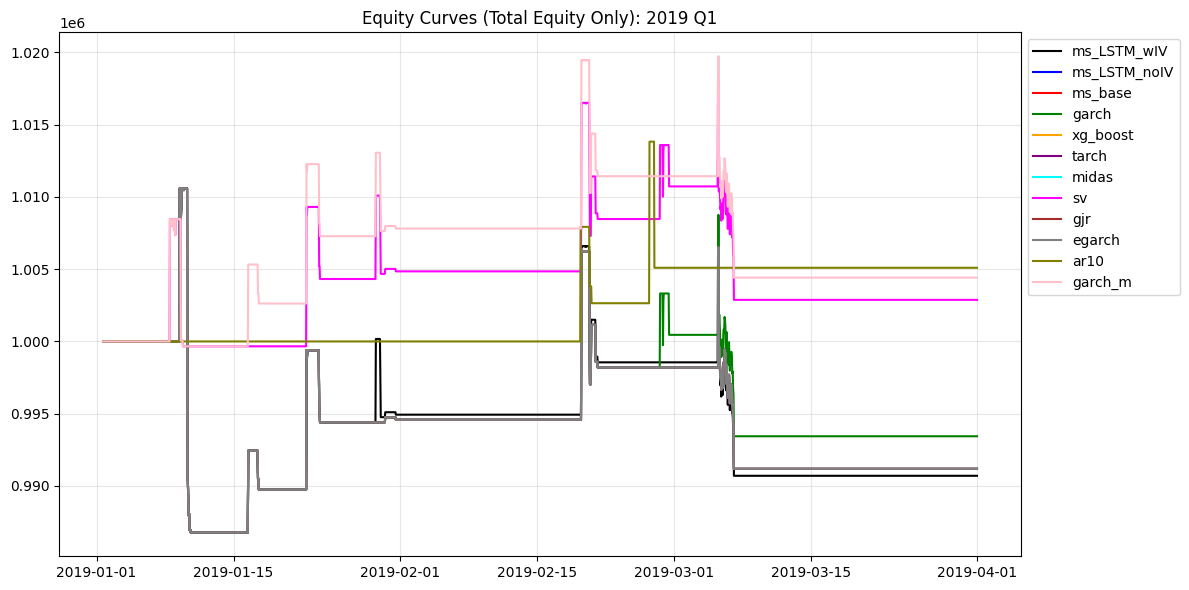

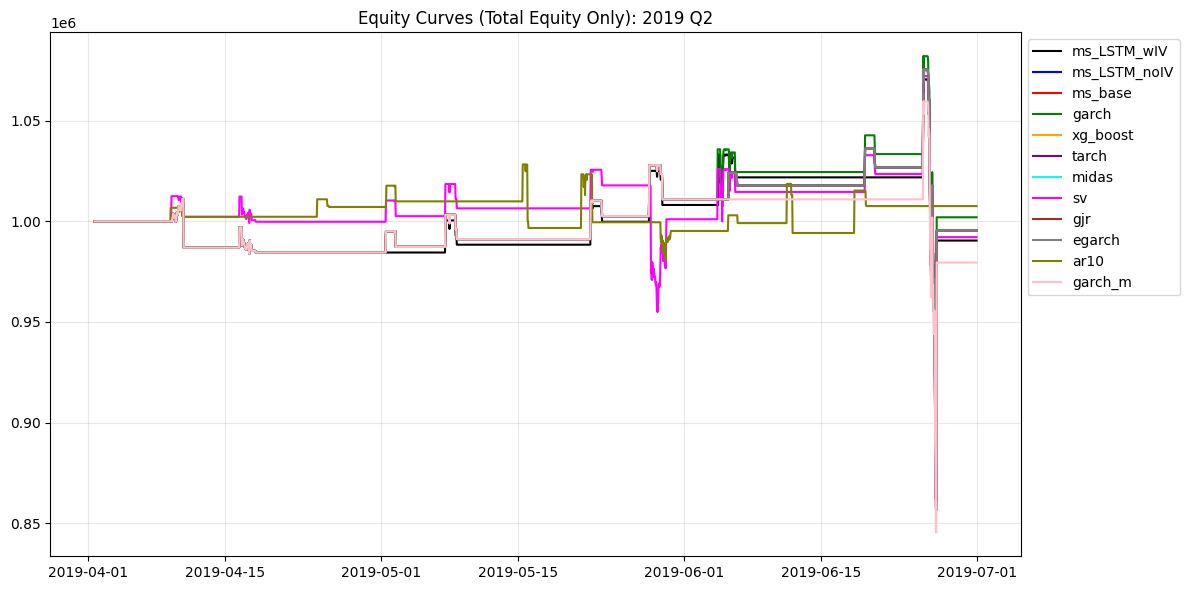

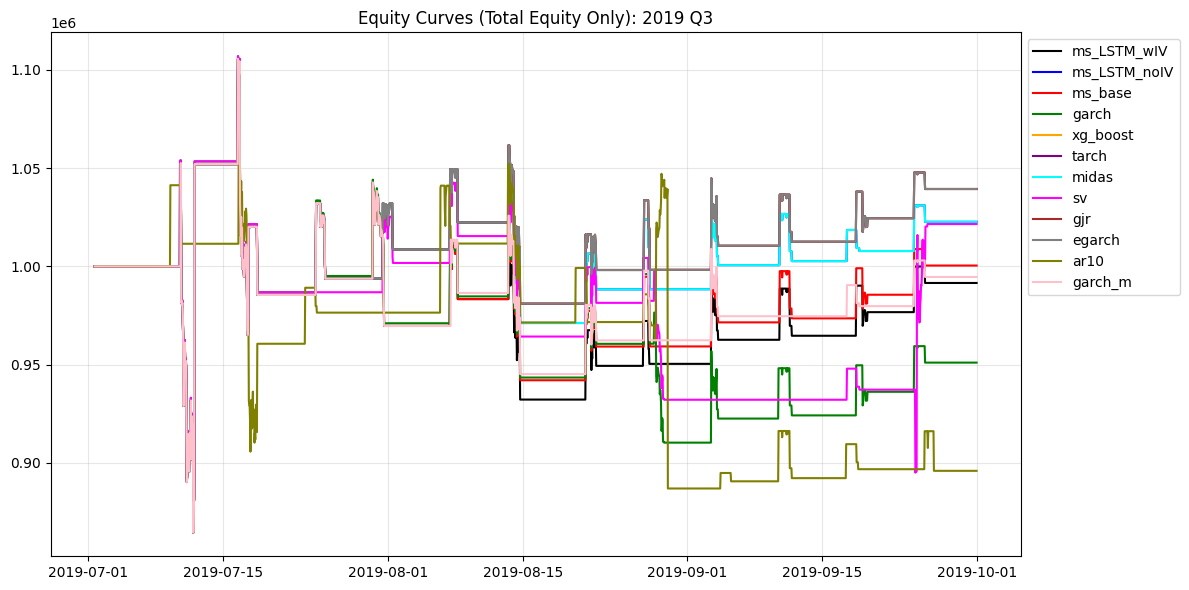

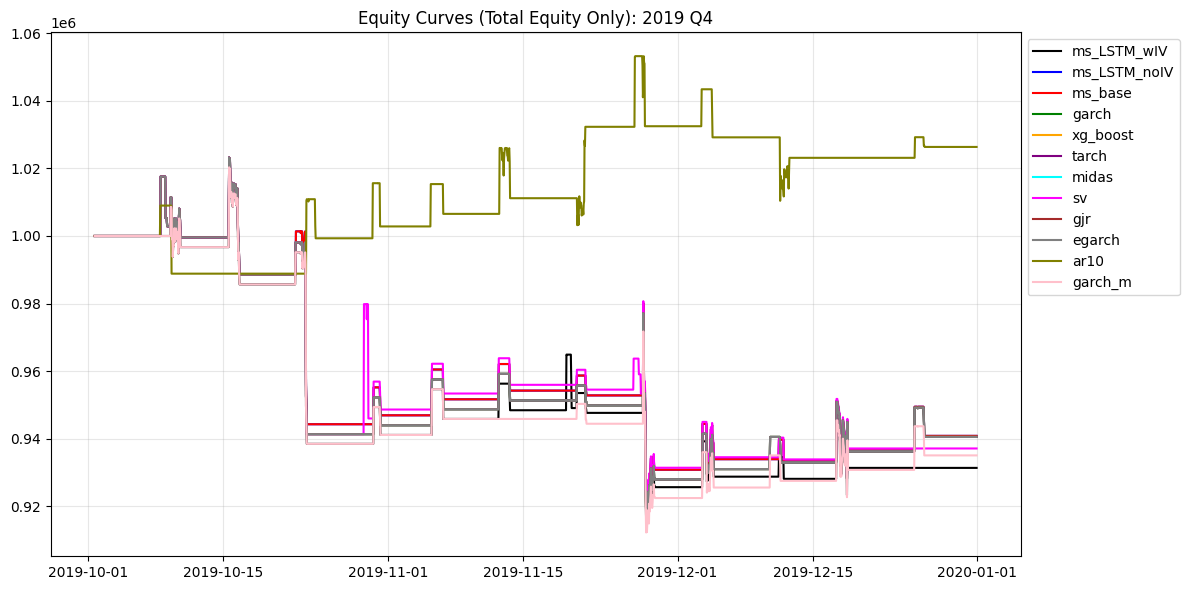

In [50]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray",
    "ar10": "olive", "garch_m": "pink"
}

for y in [2019]: 
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the equity col
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list ortuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

In [130]:
outputs_by_year[2019]['q1'].columns

Index(['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m'],
      dtype='str')

In [ ]:
# import pickle

# data_to_dump = {
#     "ms_LSTM_wIV_19_q1": ms_LSTM_wIV_19_q1,
#     "ms_LSTM_noIV_19_q1": ms_LSTM_noIV_19_q1,
#     "ms_base_19_q1": ms_base_19_q1,
#     "garch_19_q1": garch_19_q1,
#     "xg_boost_19_q1": xg_boost_19_q1,
#     "tarch_19_q1": tarch_19_q1,
#     "midas_19_q1": midas_19_q1,
#     "sv_19_q1": sv_19_q1,
#     "gjr_19_q1": gjr_19_q1,
#     "egarch_19_q1": egarch_19_q1,
#     "ar10_19_q1": ar10_19_q1,
#     "garch_m_19_q1": garch_m_19_q1,

#     "ms_LSTM_wIV_19_q2": ms_LSTM_wIV_19_q2,
#     "ms_LSTM_noIV_19_q2": ms_LSTM_noIV_19_q2,
#     "ms_base_19_q2": ms_base_19_q2,
#     "garch_19_q2": garch_19_q2,
#     "xg_boost_19_q2": xg_boost_19_q2,
#     "tarch_19_q2": tarch_19_q2,
#     "midas_19_q2": midas_19_q2,
#     "sv_19_q2": sv_19_q2,
#     "gjr_19_q2": gjr_19_q2,
#     "egarch_19_q2": egarch_19_q2,
#     "ar10_19_q2": ar10_19_q2,
#     "garch_m_19_q2": garch_m_19_q2,

#     "ms_LSTM_wIV_19_q3": ms_LSTM_wIV_19_q3,
#     "ms_LSTM_noIV_19_q3": ms_LSTM_noIV_19_q3,
#     "ms_base_19_q3": ms_base_19_q3,
#     "garch_19_q3": garch_19_q3,
#     "xg_boost_19_q3": xg_boost_19_q3,
#     "tarch_19_q3": tarch_19_q3,
#     "midas_19_q3": midas_19_q3,
#     "sv_19_q3": sv_19_q3,
#     "gjr_19_q3": gjr_19_q3,
#     "egarch_19_q3": egarch_19_q3,
#     "ar10_19_q3": ar10_19_q3,
#     "garch_m_19_q3": garch_m_19_q3,

#     "ms_LSTM_wIV_19_q4": ms_LSTM_wIV_19_q4,
#     "ms_LSTM_noIV_19_q4": ms_LSTM_noIV_19_q4,
#     "ms_base_19_q4": ms_base_19_q4,
#     "garch_19_q4": garch_19_q4,
#     "xg_boost_19_q4": xg_boost_19_q4,
#     "tarch_19_q4": tarch_19_q4,
#     "midas_19_q4": midas_19_q4,
#     "sv_19_q4": sv_19_q4,
#     "gjr_19_q4": gjr_19_q4,
#     "egarch_19_q4": egarch_19_q4,
#     "ar10_19_q4": ar10_19_q4,
#     "garch_m_19_q4": garch_m_19_q4,
# }

# with open(r"..\strategy_outputs\2019_2022\backtest_results_2019.pkl", "wb") as f:
#     pickle.dump(data_to_dump, f)

### Testing Strategy 01_30 (2020)

In [51]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2020.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2020.parquet")

In [52]:
market = Market(df,d_btc, starting_cash = 1000000)

### 2020

In [53]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2020 only
target_years = [2020]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2023")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 10
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2020.")

Processing 2020 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (8000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7750.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8750.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8250.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8250.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8250.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8250.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (8250.0, Timestamp('2020-01-17 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-31 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (8750.0, Timestamp('2020-01-31 00:00:

Processing 2020 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [00:25<19:53, 25.40s/it]

Liquidate this option: (6500.0, Timestamp('2020-04-01 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (6375.0, Timestamp('2020-04-01 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (7000.0, Timestamp('2020-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (9250.0, Timestamp('2020-01-10 00:00:

Processing 2020 q1 | ms_base:   4%|▍         | 2/48 [00:48<18:15, 23.81s/it]     

...

Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (26500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (10750.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10625.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (10750.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10625.0, Timestamp('2020-10-07 00

Processing 2020 q4 | garch_m:  98%|█████████▊| 47/48 [2:35:54<00:37, 37.32s/it]

Liquidate this option: (29000.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27500.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (11250.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10125.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (11250.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10125.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (11250.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10125.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (11250.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (10125.0, Timestamp('2020-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (11250.0, Timestamp('2020-1

Processing 2020 q4 | garch_m: 100%|██████████| 48/48 [2:36:22<00:00, 195.46s/it]

Liquidate this option: (31000.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27000.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (31000.0, Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 'C', 'sell')

Execution Finished for 2020.


### Equity Line 01_30 (2020)

In [ ]:
# import pickle

# with open('../strategy_outputs/backtest_results_2020.pkl', 'rb') as f:
#     globals().update(pickle.load(f))

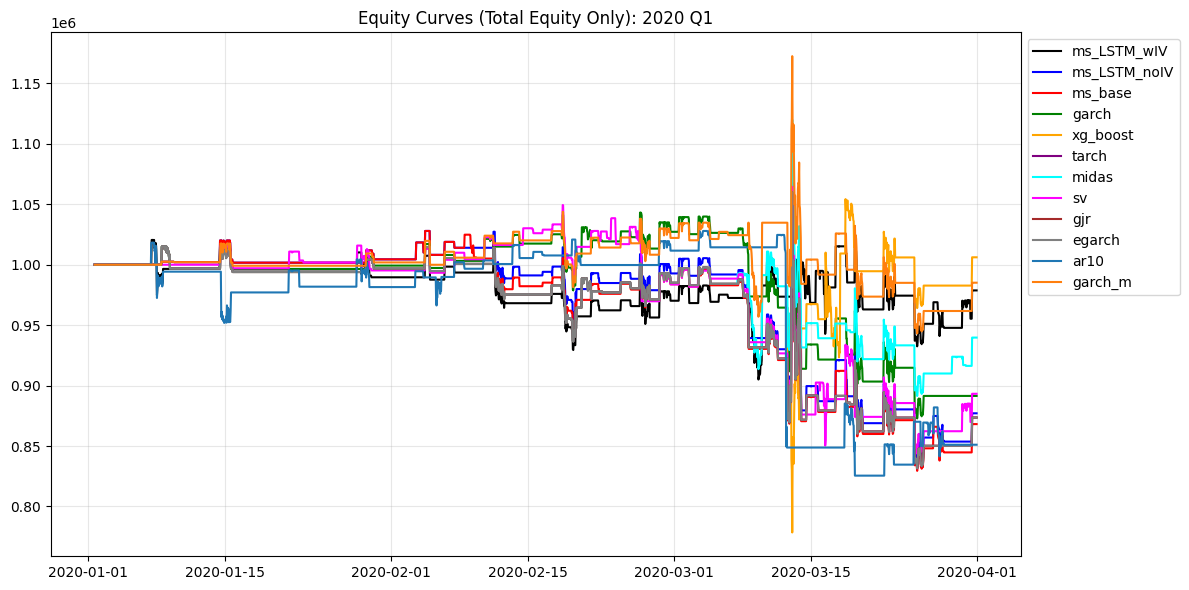

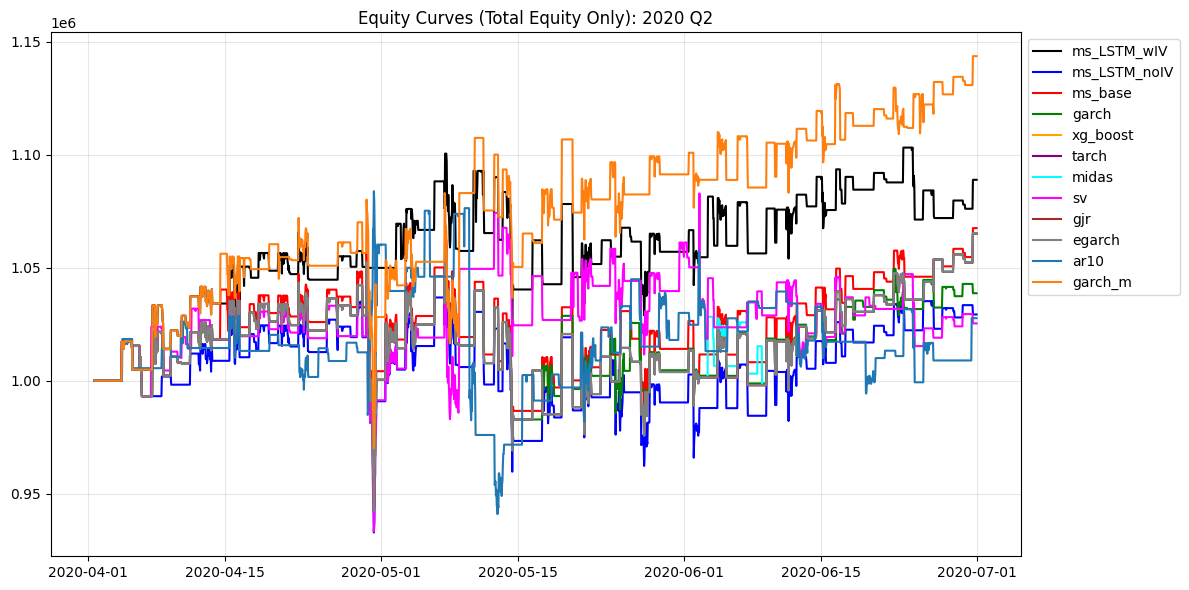

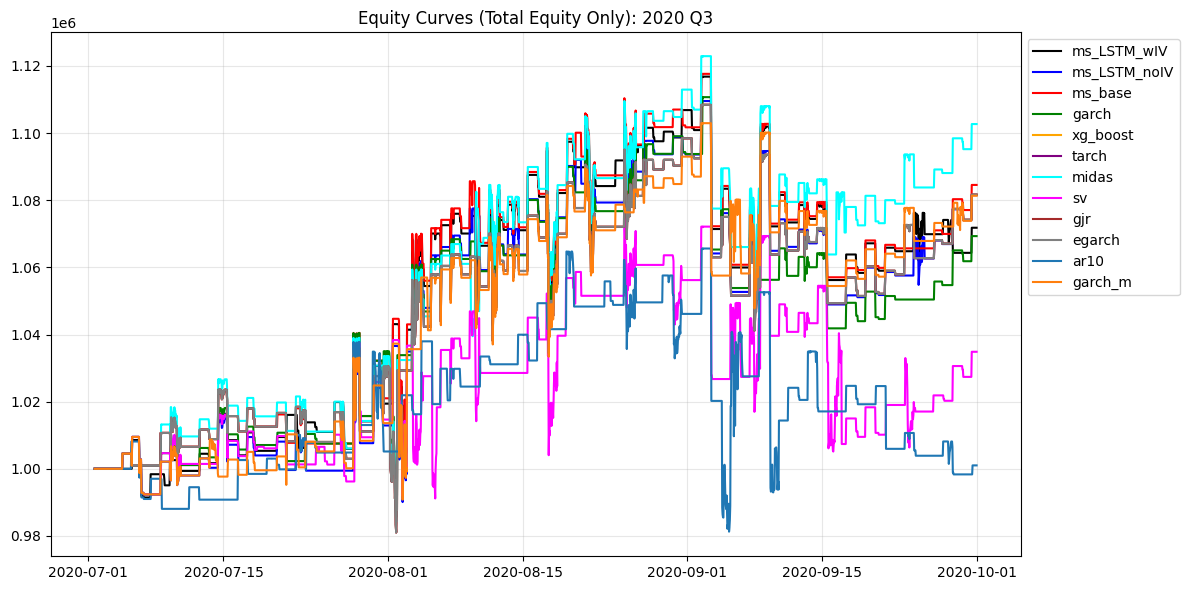

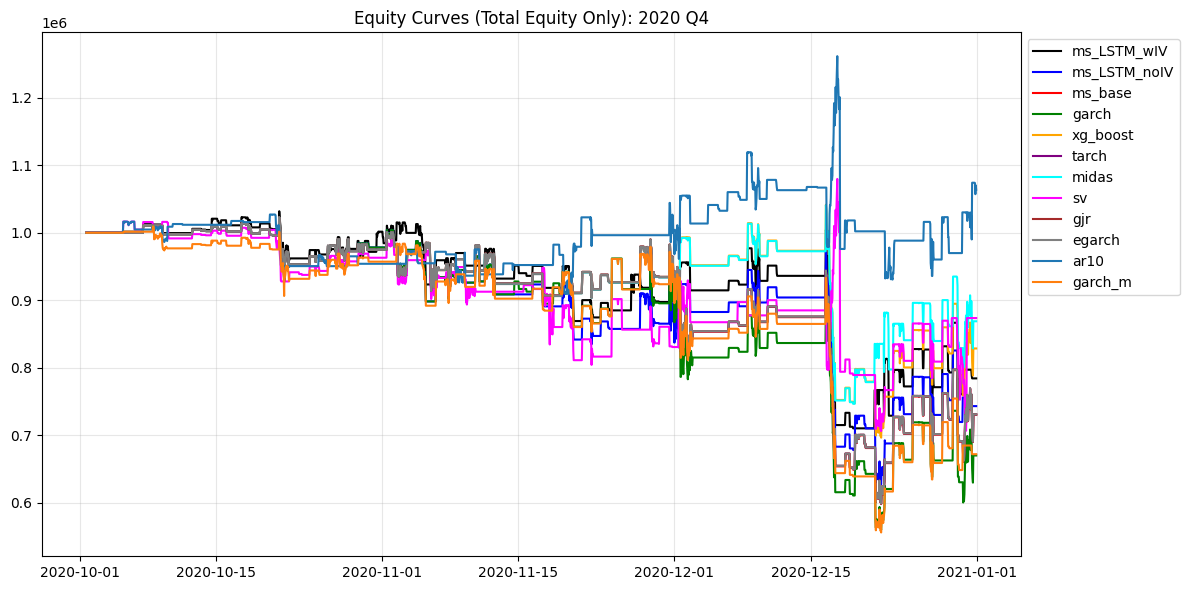

In [54]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [2020]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### Testing Strategy 01_30 (2021)

In [55]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2021.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2021.parquet")

### 2021

In [56]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]


strategy_results = {}


target_years = [2021]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2021")

for y in target_years:
    # Ensure 2024 actually exists in your data
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            # Resetting market for each specific model run
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 10
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2021.")

Processing 2021 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (31000.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (38000.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (36500.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (38000.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (36500.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (41000.0, Timestamp('2021-01-12 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (40000.0, Timestamp('2021-01-12 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (41000.0, Timestamp('2021-0

Processing 2021 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [01:00<47:34, 60.73s/it]

Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (31000.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (32500.0, Timestamp('2021-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (38000.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (36500.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (38000.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (36500.0, Timestamp('2021-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (41000.0, Timestamp('2021-01-12 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (40000.0, Timestamp('2021-01-12 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (41000.0, Timestamp('2021-0

Processing 2021 q1 | ms_base:   4%|▍         | 2/48 [02:00<46:08, 60.18s/it]     

...

Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (46000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (46000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (46000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (49000.0, Timestamp('2021-1

Processing 2021 q4 | garch_m:  98%|█████████▊| 47/48 [44:20<00:50, 50.07s/it]

Liquidate this option: (50000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (50000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (50000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-10-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (47000.0, Timestamp('2021-1

Processing 2021 q4 | garch_m: 100%|██████████| 48/48 [45:10<00:00, 56.46s/it]


Execution Finished for 2021.


### Equity Line (2021)

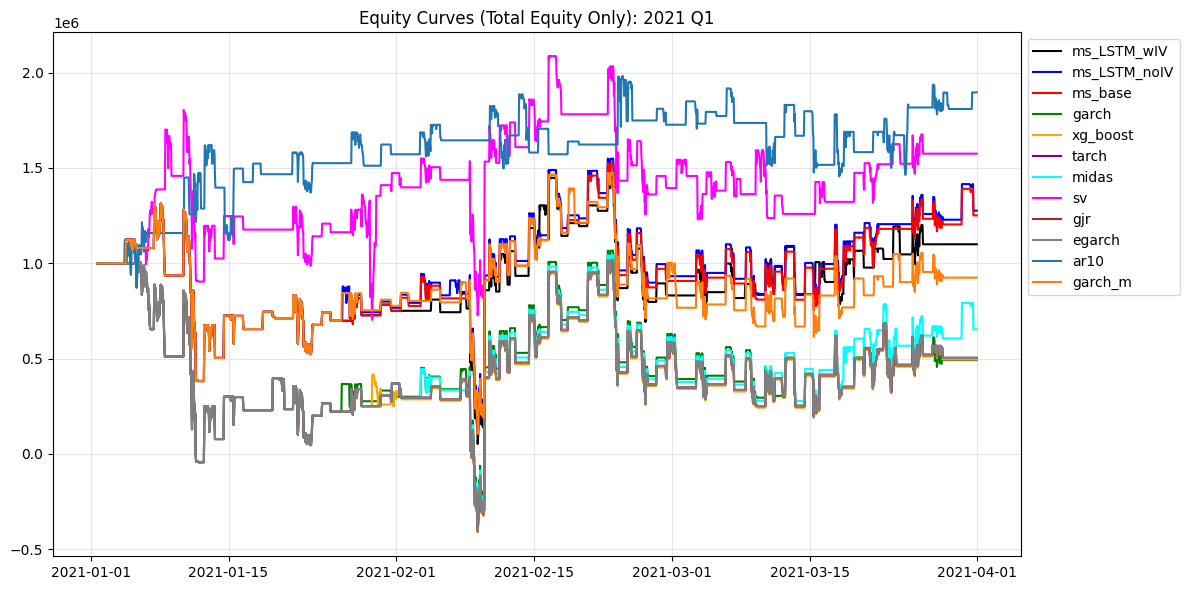

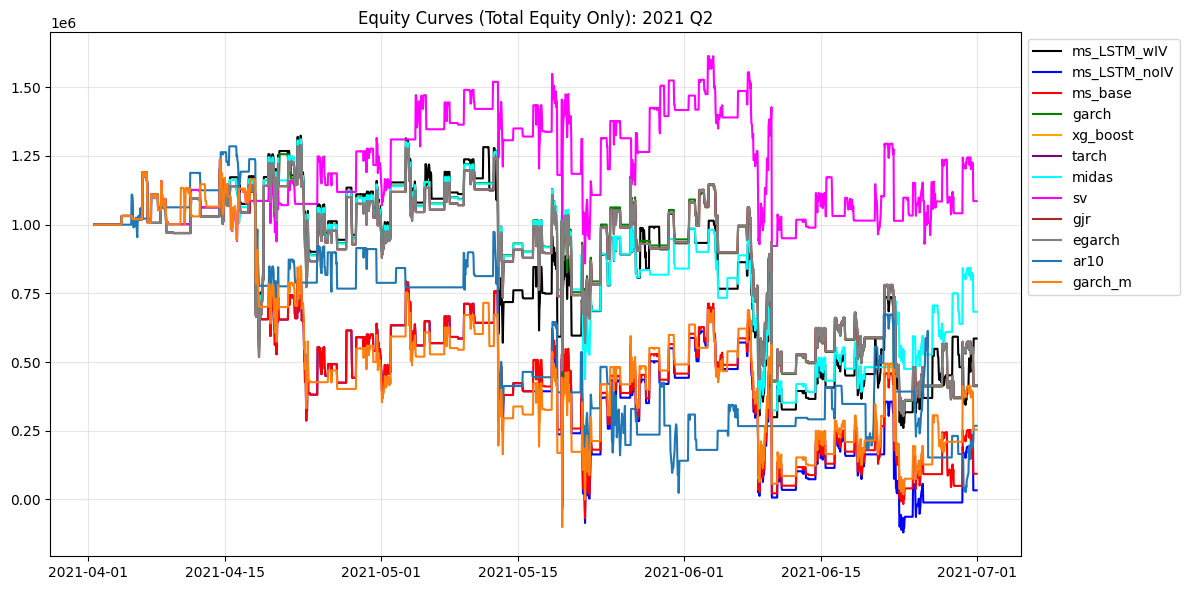

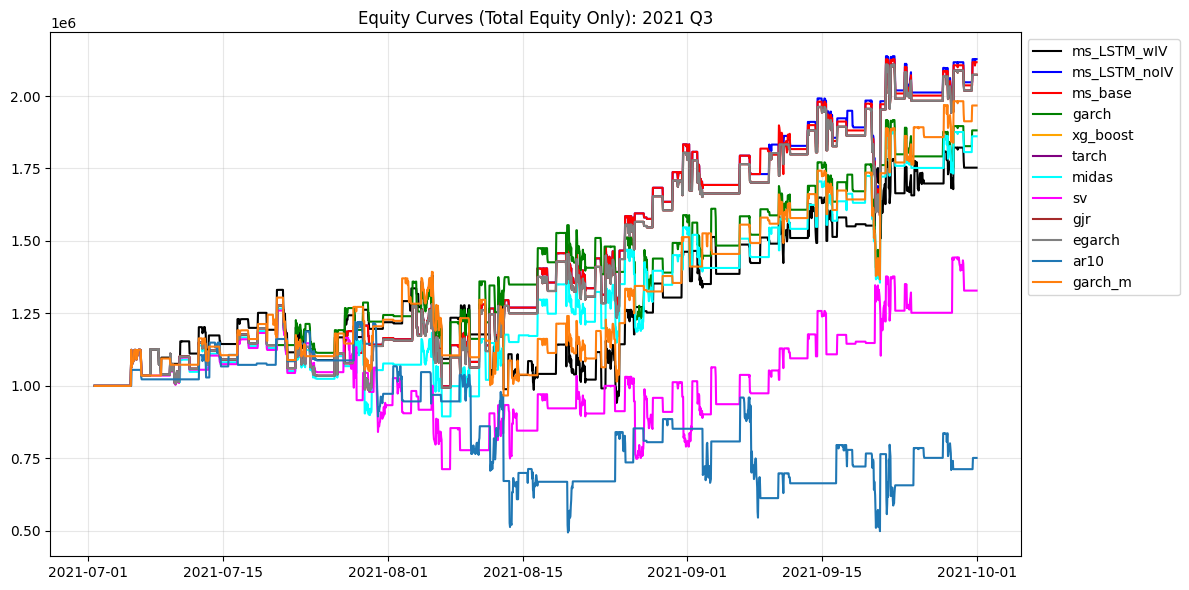

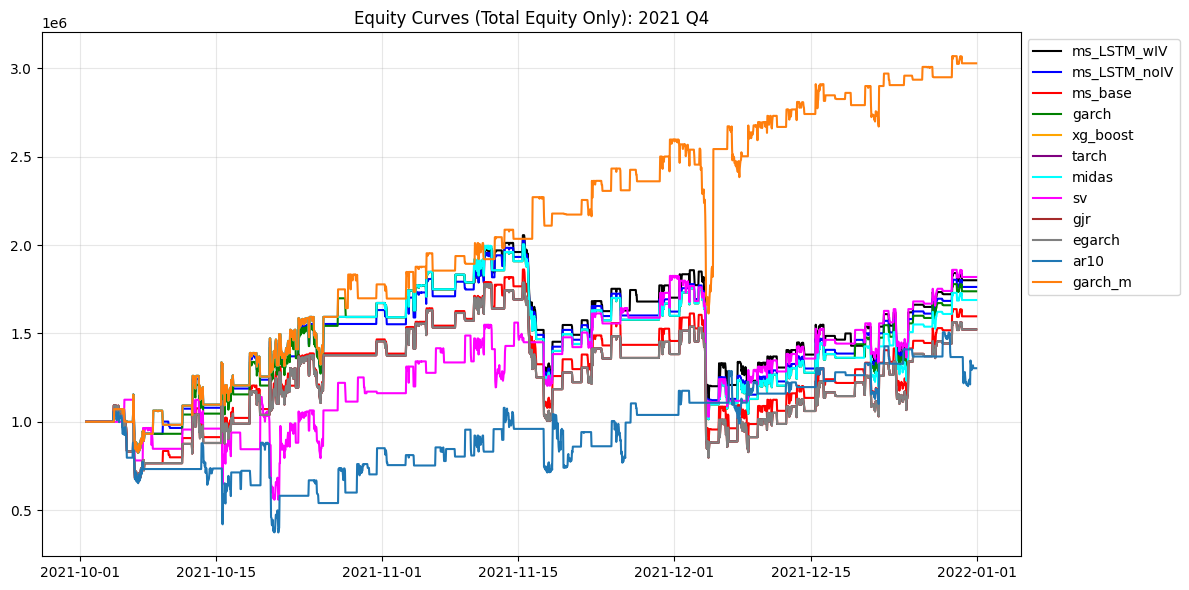

In [57]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [2021]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### Kharooj